# Inference Monitoring Notebook

Post-deployment monitoring workflow for the fraud detection model:

1. **Single Inference Test** — Invoke the endpoint with individual samples (JSON format)
2. **Batch Inference Test** — Bulk predictions with latency stats
3. **Ground Truth Simulation** — Generate simulated ground truth for testing (dev/test only)
4. **Ground Truth Update** — Apply ground truth to inference records
5. **Monitoring Runs** — Data drift + model drift detection with MLflow logging

**Quick Start:**
1. Run Cells 1-2 to setup
2. Run Cells 6-9 to generate inference predictions (automatically logged to Athena by custom handler)
3. Run Section 3.1 to simulate ground truth (for development/testing)
4. Run Section 3.2 to verify coverage
5. Run Section 4 to monitor drift and performance

**Important Notes:**
- The endpoint uses a **custom inference handler** that automatically logs all predictions to Athena
- Input format: **JSON** (not CSV) with 30 training features
- Predictions are buffered and flushed to Athena asynchronously (50 records or 5 minutes)
- No manual logging needed - happens automatically in the background

**Environment:** SageMaker AI Notebook or local with AWS credentials.

## Setup

In [1]:
import sys, os, json, time, logging, uuid
from pathlib import Path
from datetime import datetime, timedelta

import boto3
import pandas as pd
import numpy as np

# Find project root and add to path
project_root = Path.cwd()
while not (project_root / '.env').exists() and project_root != project_root.parent:
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from dotenv import load_dotenv
load_dotenv(project_root / '.env')

from src.config.config import (
    ATHENA_DATABASE, DATA_S3_BUCKET, AWS_REGION,
    TABLE_INFERENCE_RESPONSES, TABLE_GROUND_TRUTH_UPDATES,
    CSV_TRAINING_DATA, FEATURE_COLUMNS, TARGET_COLUMN,
    SAGEMAKER_EXEC_ROLE, MLFLOW_MODEL_NAME,
)
from src.pipeline.athena.athena_client import AthenaClient

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

ENDPOINT_NAME = 'fraud-detector-endpoint'
REGION = AWS_REGION

runtime_client = boto3.client('sagemaker-runtime', region_name=REGION)
sm_client = boto3.client('sagemaker', region_name=REGION)
athena_client = AthenaClient()

print(f'Region: {REGION}')
print(f'Endpoint: {ENDPOINT_NAME}')
print(f'Athena DB: {ATHENA_DATABASE}')
print(f'S3 Bucket: {DATA_S3_BUCKET}')

2026-03-15 20:22:12,836 - INFO - Initialized AthenaClient for database: fraud_detection


Region: us-east-1
Endpoint: fraud-detector-endpoint
Athena DB: fraud_detection
S3 Bucket: fraud-detection-data-lake-skoppar-146666888814


## 1. Single Inference Test

Invoke the deployed serverless endpoint with individual samples to verify it's working.

In [2]:
# Load sample data for testing
test_df = pd.read_csv(CSV_TRAINING_DATA)
print(f'Loaded {len(test_df):,} rows from {CSV_TRAINING_DATA.name}')

# Exact feature list from preprocessing (feature_metadata.json in S3)
# These are the 30 features the model was trained on, in order.
TRAINING_FEATURES = [
    'transaction_hour', 'transaction_day_of_week', 'transaction_amount',
    'transaction_type_code', 'customer_age', 'customer_gender',
    'customer_tenure_months', 'account_age_days', 'distance_from_home_km',
    'distance_from_last_transaction_km', 'time_since_last_transaction_min',
    'online_transaction', 'international_transaction', 'high_risk_country',
    'merchant_category_code', 'merchant_reputation_score', 'chip_transaction',
    'pin_used', 'card_present', 'cvv_match', 'address_verification_match',
    'num_transactions_24h', 'num_transactions_7days',
    'avg_transaction_amount_30days', 'max_transaction_amount_30days',
    'velocity_score', 'recurring_transaction', 'previous_fraud_incidents',
    'credit_limit', 'available_credit_ratio',
]

# Encode customer_gender (string -> int) same as preprocessing
if 'customer_gender' in test_df.columns and test_df['customer_gender'].dtype == 'object':
    unique_vals = sorted(test_df['customer_gender'].dropna().unique())
    mapping = {val: idx for idx, val in enumerate(unique_vals)}
    test_df['customer_gender'] = test_df['customer_gender'].map(mapping).fillna(-1).astype(int)
    print(f'Encoded customer_gender: {mapping}')

# Verify all features exist in the CSV
missing = [f for f in TRAINING_FEATURES if f not in test_df.columns]
if missing:
    print(f'⚠ Missing features: {missing}')
else:
    print(f'✓ All {len(TRAINING_FEATURES)} training features found')

feature_cols = TRAINING_FEATURES
print(f'Feature columns for inference: {len(feature_cols)}')
test_df.head(3)

Loaded 284,807 rows from creditcard_predictions_final.csv
Encoded customer_gender: {'Female': 0, 'Male': 1, 'Other': 2}
✓ All 30 training features found
Feature columns for inference: 30


,transaction_id,transaction_timestamp,transaction_hour,transaction_day_of_week,customer_age,account_age_days,merchant_category_code,distance_from_home_km,distance_from_last_transaction_km,online_transaction,...,transaction_type_code,customer_tenure_months,credit_limit,available_credit_ratio,previous_fraud_incidents,transaction_amount,fraud_prediction,fraud_probability,customer_gender,is_fraud
0,0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,False,0.133346,1,False
1,1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,False,0.082565,0,False
2,2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,False,0.082565,2,False


In [4]:
# Quick test - verify endpoint uses custom handler with JSON format
import boto3, json

# Test with a single sample using JSON format (custom handler)
test_payload = {
    "transaction_hour": 14,
    "transaction_day_of_week": 2,
    "transaction_amount": 149.62,
    "transaction_type_code": 1,
    "customer_age": 42,
    "customer_gender": 0,
    "customer_tenure_months": 36,
    "account_age_days": 1095,
    "distance_from_home_km": 5.2,
    "distance_from_last_transaction_km": 2.3,
    "time_since_last_transaction_min": 120,
    "online_transaction": 1,
    "international_transaction": 0,
    "high_risk_country": 0,
    "merchant_category_code": 5411,
    "merchant_reputation_score": 0.85,
    "chip_transaction": 1,
    "pin_used": 1,
    "card_present": 1,
    "cvv_match": 1,
    "address_verification_match": 1,
    "num_transactions_24h": 3,
    "num_transactions_7days": 12,
    "avg_transaction_amount_30days": 125.50,
    "max_transaction_amount_30days": 450.00,
    "velocity_score": 0.3,
    "recurring_transaction": 0,
    "previous_fraud_incidents": 0,
    "credit_limit": 5000.0,
    "available_credit_ratio": 0.75
}

runtime = boto3.client('sagemaker-runtime', region_name='us-east-1')
response = runtime.invoke_endpoint(
    EndpointName='fraud-detector-endpoint',
    ContentType='application/json',  # Custom handler expects JSON
    Body=json.dumps(test_payload)
)
result = json.loads(response['Body'].read().decode())
print(f"Response: {result}")
print(f"  Prediction: {result['predictions'][0]}")
print(f"  Fraud probability: {result['probabilities']['fraud'][0]:.4f}")

2026-03-15 20:23:03,105 - INFO - Loading cached SSO token for default


Response: {'predictions': [0], 'probabilities': {'non_fraud': [0.9999009966850281], 'fraud': [9.900043369270861e-05]}}
  Prediction: 0
  Fraud probability: 0.0001


In [5]:
def invoke_endpoint_json(endpoint_name, feature_dict):
    """Invoke endpoint with JSON format (custom handler with Athena logging)."""
    import json
    import time
    
    payload = json.dumps(feature_dict)
    start = time.time()
    
    response = runtime_client.invoke_endpoint(
        EndpointName=endpoint_name,
        ContentType='application/json',  # Custom handler expects JSON
        Body=payload
    )
    
    latency_ms = (time.time() - start) * 1000
    result = json.loads(response['Body'].read().decode())
    
    # Custom handler returns: {"predictions": [0], "probabilities": {"fraud": [0.1234], "non_fraud": [0.8766]}}
    fraud_prob = result["probabilities"]["fraud"][0]
    prediction = result["predictions"][0]
    
    return {'prediction': prediction, 'fraud_probability': fraud_prob}, latency_ms


# Test with a few samples
NUM_SINGLE_TESTS = 5
samples = test_df.sample(n=NUM_SINGLE_TESTS, random_state=42)

print(f'Testing {NUM_SINGLE_TESTS} individual invocations ({len(feature_cols)} features)...\n')
for i, (idx, row) in enumerate(samples.iterrows(), 1):
    feature_dict = row[feature_cols].to_dict()
    actual_label = row.get('is_fraud', 'N/A')

    result, latency = invoke_endpoint_json(ENDPOINT_NAME, feature_dict)

    print(f'Sample {i}: prediction={result["prediction"]}, '
          f'fraud_prob={result["fraud_probability"]:.4f}, '
          f'actual={actual_label}, latency={latency:.0f}ms')

print('\n✓ Single inference tests complete')

Testing 5 individual invocations (30 features)...

Sample 1: prediction=1, fraud_prob=0.9999, actual=True, latency=618ms
Sample 2: prediction=0, fraud_prob=0.0000, actual=False, latency=160ms
Sample 3: prediction=0, fraud_prob=0.0001, actual=False, latency=140ms
Sample 4: prediction=0, fraud_prob=0.0001, actual=False, latency=137ms
Sample 5: prediction=0, fraud_prob=0.0001, actual=False, latency=145ms

✓ Single inference tests complete


### SageMaker Studio Endpoint Playground

**Access:** SageMaker Studio > Deployments > Endpoints > Fraud Detector Endpoint > Playground

Copy the JSON payload below and paste it into the endpoint playground.

**Configuration:**
- Content-Type: `application/json`
- Format: JSON with 30 training features

**Important:** The custom inference handler expects JSON format, not CSV.

SageMaker Studio Endpoint Playground - Sample Payloads
Endpoint: fraud-detector-endpoint
Content-Type: application/json
Features: 30

--- Sample 1 (actual is_fraud=False) ---
{
  "transaction_hour": 0.16201717763963,
  "transaction_day_of_week": 0.135609986241546,
  "transaction_amount": 210.45,
  "transaction_type_code": 1.19822605279657,
  "customer_age": 0.363988417369092,
  "customer_gender": 0,
  "customer_tenure_months": -0.632712168975863,
  "account_age_days": 0.311418002684095,
  "distance_from_home_km": 0.0909844149119447,
  "distance_from_last_transaction_km": 1.63464525620435,
  "time_since_last_transaction_min": -0.0311513654152596,
  "online_transaction": -0.716743163693201,
  "international_transaction": -0.0276030707164521,
  "high_risk_country": 0.430925314226742,
  "merchant_category_code": -0.203775089261961,
  "merchant_reputation_score": 1.63159316908859,
  "chip_transaction": 0.258082086467721,
  "pin_used": 0.176258196099758,
  "card_present": -0.0234190544123169

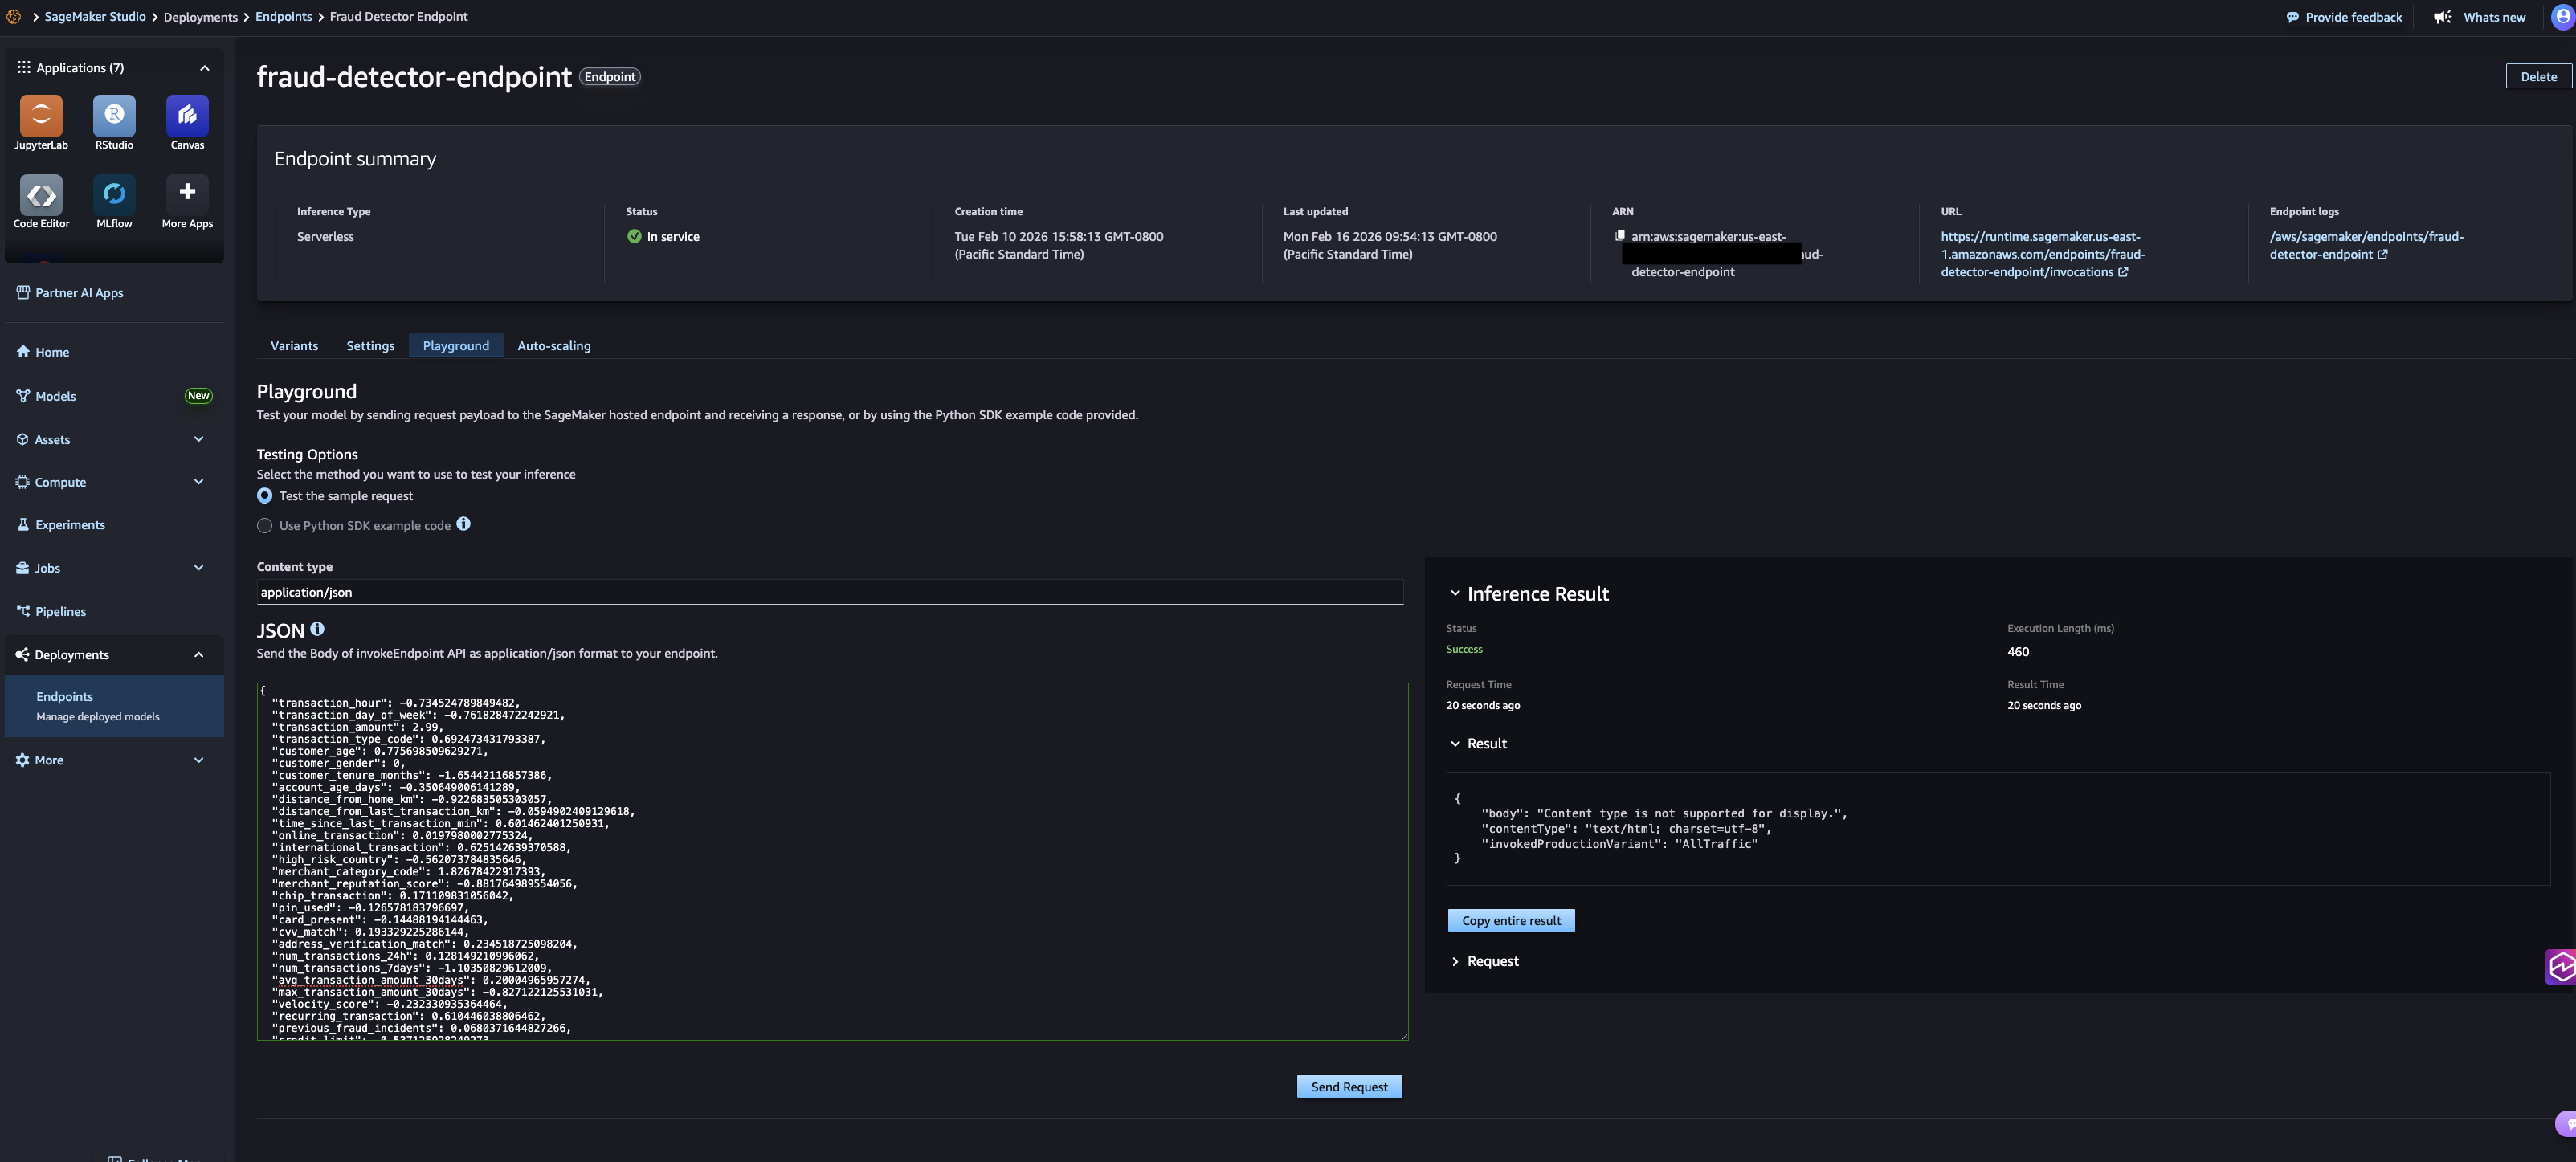

In [6]:
# Generate sample JSON payloads for SageMaker Studio endpoint playground
# Content-Type: application/json

# Verify feature count before generating samples
assert len(feature_cols) == 30, f"Expected 30 features, got {len(feature_cols)}"

num_playground_samples = 3
playground_samples = test_df.sample(n=num_playground_samples, random_state=99)

print('=' * 80)
print('SageMaker Studio Endpoint Playground - Sample Payloads')
print(f'Endpoint: {ENDPOINT_NAME}')
print(f'Content-Type: application/json')
print(f'Features: {len(feature_cols)}')
print('=' * 80)

for i, (idx, row) in enumerate(playground_samples.iterrows(), 1):
    feature_dict = row[feature_cols].to_dict()
    # Convert to JSON string
    json_payload = json.dumps(feature_dict, indent=2)
    actual = row.get('is_fraud', '?')
    print(f'\n--- Sample {i} (actual is_fraud={actual}) ---')
    print(json_payload)

print('\n' + '=' * 80)
print('Copy any JSON object above and paste into the endpoint playground.')
print('Expected response format:')
print('  {"predictions": [0], "probabilities": {"fraud": [0.1234], "non_fraud": [0.8766]}}')

# Display screenshot showing how to use the SageMaker Studio Endpoint Playground
from IPython.display import Image, display
screenshot_path = project_root / 'screenshots' / 'DirectTestingInSGPlayground-custom-handler.png'
if screenshot_path.exists():
    print('\n\nHow to test in SageMaker Studio Endpoint Playground:')
    display(Image(filename=str(screenshot_path), width=800))
else:
    print(f'\n⚠ Screenshot not found at: {screenshot_path}')

In [7]:
# Bulk JSON invocation test with latency stats
NUM_BULK_TESTS = 101
bulk_samples = test_df.sample(n=NUM_BULK_TESTS, random_state=123)

predictions = []
latencies = []
errors = []

print(f'Running {NUM_BULK_TESTS} JSON invocations...')
for idx, row in bulk_samples.iterrows():
    try:
        feature_dict = row[feature_cols].to_dict()
        result, latency = invoke_endpoint_json(ENDPOINT_NAME, feature_dict)
        predictions.append(result)
        latencies.append(latency)
    except Exception as e:
        errors.append(str(e))

latencies_arr = np.array(latencies)
print(f'\nResults:')
print(f'  Successful: {len(predictions)}/{NUM_BULK_TESTS}')
print(f'  Errors: {len(errors)}')
print(f'  Avg latency: {latencies_arr.mean():.0f}ms')
print(f'  P50 latency: {np.percentile(latencies_arr, 50):.0f}ms')
print(f'  P95 latency: {np.percentile(latencies_arr, 95):.0f}ms')
print(f'  P99 latency: {np.percentile(latencies_arr, 99):.0f}ms')

# Prediction distribution
fraud_preds = sum(1 for p in predictions if p['prediction'] == 1)
print(f'  Fraud predictions: {fraud_preds}/{len(predictions)} ({fraud_preds/len(predictions)*100:.1f}%)')

Running 101 JSON invocations...

Results:
  Successful: 101/101
  Errors: 0
  Avg latency: 136ms
  P50 latency: 135ms
  P95 latency: 162ms
  P99 latency: 172ms
  Fraud predictions: 1/101 (1.0%)


In [8]:
# ✓ Automatic Athena Logging Enabled
# The custom inference handler automatically logs all predictions to Athena.
# No manual logging needed!

# How it works:
# - Every prediction is captured by the custom handler
# - Records are buffered in memory (up to 50 records)
# - Automatic flush happens when:
#   1. Buffer reaches 50 records (batch flush)
#   2. 5 minutes have elapsed (time flush)
#   3. Endpoint shuts down (graceful flush)

# Verify automatic logging:
print("Checking automatic Athena logging...")

query = f"""
SELECT COUNT(*) as total,
       CAST(MIN(request_timestamp) AS TIMESTAMP(3)) as earliest,
       CAST(MAX(request_timestamp) AS TIMESTAMP(3)) as latest
FROM {ATHENA_DATABASE}.inference_responses
"""
#WHERE endpoint_name = '{ENDPOINT_NAME}'
result = athena_client.execute_query(query)

if not result.empty:
    print(f"✓ Found {result['total'].iloc[0]:,} predictions in Athena")
    print(f"  Time range: {result['earliest'].iloc[0]} to {result['latest'].iloc[0]}")
    print(f"\nAutomatic logging is working! No manual step needed.")
else:
    print("⚠ No predictions found yet.")
    print("  Run cells 6-9 to generate predictions.")
    print("  Wait for buffer to flush (50 records or 5 minutes)")

2026-03-15 20:25:22,735 - INFO - Executing query: 
SELECT COUNT(*) as total,
       CAST(MIN(request_timestamp) AS TIMESTAMP(3)) as earliest,
       C...


Checking automatic Athena logging...


2026-03-15 20:25:27,441 - INFO - Query returned 1 rows


✓ Found 1,191 predictions in Athena
  Time range: 2026-02-21 15:37:18.814000 to 2026-03-16 03:23:44.670000

Automatic logging is working! No manual step needed.


## 3. Ground Truth Simulation & Update

In production, ground truth arrives asynchronously as fraud investigations complete. For development and testing, we can simulate ground truth to test the monitoring pipeline.

**Workflow:**
1. **Simulate Ground Truth** (Section 3.1) — Generate realistic fraud/non-fraud labels
2. **Apply Updates** (Section 3.1) — Merge simulated ground truth into inference_responses
3. **Verify Coverage** (Section 3.2) — Confirm ground truth is applied

**Production Note:** In a real production environment, ground truth would come from your fraud investigation system that writes confirmed fraud/non-fraud labels to the `ground_truth_updates` Athena table. The simulation is only for development and testing.

### 3.2 Verify Ground Truth Coverage

After simulating and applying ground truth updates, verify the coverage to ensure predictions now have ground truth labels.

In [9]:
# Apply simulated ground truth updates to inference_responses table
print("Applying ground truth updates to inference_responses table...")

# Initialize updater (already imported above)
if 'updater' not in dir():
    from src.monitoring.update_ground_truth import GroundTruthUpdater
    updater = GroundTruthUpdater(athena_client=athena_client, dry_run=False)

# Get statistics before update
print("\nGetting update statistics...")
update_stats = updater.get_update_statistics()

if update_stats['total_updates'] > 0:
    print(f"\nPending updates: {update_stats['total_updates']:,}")
    print(f"  Fraud cases: {update_stats['fraud_cases']:,}")
    print(f"  False positives: {update_stats['false_positives']:,}")
    print(f"  False negatives: {update_stats['false_negatives']:,}")
    print(f"  Avg days to confirmation: {update_stats['avg_days_to_confirmation']:.1f}")
    
    # Execute the update
    print("\nMerging ground truth updates into inference_responses...")
    result = updater.update_ground_truth_batch()
    
    print(f"\n✅ Ground truth update complete!")
    print(f"   Records updated: {result['updated']:,}")
    print(f"\n   Next: Run Cell 16 to check coverage")
else:
    print("\n⚠️  No pending updates found")
    print("   Make sure you ran the simulation cell above first")

2026-03-15 20:25:30,888 - INFO - Calculating update statistics...
2026-03-15 20:25:30,889 - INFO - Executing query: 
        SELECT
            COUNT(*) as total_updates,
            COALESCE(SUM(CAST(gtu.actual_frau...


Applying ground truth updates to inference_responses table...

Getting update statistics...


2026-03-15 20:25:35,320 - INFO - Query returned 1 rows



⚠️  No pending updates found
   Make sure you ran the simulation cell above first


In [10]:
# Option 1: Run the simulation script via command line
# Uncomment and run in terminal:
# !python scripts/simulate_ground_truth_from_athena.py --accuracy 0.85 --endpoint-name {ENDPOINT_NAME}

# Option 2: Simulate ground truth programmatically (in notebook)
from src.monitoring.simulate_ground_truth_from_athena import GroundTruthSimulator

# Create simulator with 85% accuracy (15% error rate)
simulator = GroundTruthSimulator(
    athena_client=athena_client,
    endpoint_name=ENDPOINT_NAME,
    accuracy=0.85,  # 85% of predictions will match ground truth
    fraud_confirmation_days=(1, 7),  # Fraud confirmed in 1-7 days
    non_fraud_confirmation_days=(1, 30),  # Non-fraud confirmed in 1-30 days
    seed=42
)

# Run simulation
print("Simulating ground truth for predictions without ground truth...")
stats = simulator.simulate_and_write(limit=None)  # Set limit=100 to only process 100 predictions

print("\n" + "=" * 80)
print("Simulation Summary")
print("=" * 80)

if stats['total_predictions'] > 0:
    print(f"Predictions processed: {stats['total_predictions']:,}")
    print(f"Ground truth updates created: {stats['updates_created']:,}")
    print(f"Actual fraud: {stats['actual_fraud']:,} ({stats['actual_fraud']/stats['total_predictions']*100:.1f}%)")
    print(f"False positives: {stats['false_positives']:,}")
    print(f"False negatives: {stats['false_negatives']:,}")
    print(f"Model accuracy: {stats.get('accuracy', 0.85)*100:.1f}%")
    print("=" * 80)
    print("\n✅ Ground truth simulation complete!")
    print("   Next: Run the cell below to apply updates to inference_responses table")
else:
    print("⚠️  No predictions found to simulate ground truth")
    print("   Total predictions: 0")
    print("   Possible reasons:")
    print("   - No inference tests have been run yet (run Cells 6-9)")
    print("   - All predictions already have ground truth")
    print("   - Wrong endpoint name filter")
    print("\n   Action: Run Cells 6-9 to generate inference predictions first")
    print("=" * 80)

2026-03-15 20:26:06,878 - INFO - Initialized GroundTruthSimulator with accuracy=0.85


2026-03-15 20:26:06,879 - INFO - ================================================================================
2026-03-15 20:26:06,879 - INFO - Starting Ground Truth Simulation
2026-03-15 20:26:06,880 - INFO - ================================================================================
2026-03-15 20:26:06,881 - INFO - Loading predictions without ground truth from Athena...
2026-03-15 20:26:06,881 - INFO - Executing query: 
        SELECT
            inference_id,
            transaction_id,
            CAST(request_times...


Simulating ground truth for predictions without ground truth...


2026-03-15 20:26:11,301 - INFO - Query returned 107 rows
2026-03-15 20:26:11,302 - INFO - Loaded 107 predictions without ground truth
2026-03-15 20:26:11,303 - INFO -   Predicted fraud: 2
2026-03-15 20:26:11,304 - INFO -   Predicted non-fraud: 105
2026-03-15 20:26:11,304 - INFO - Simulating ground truth with 85.0% accuracy...
2026-03-15 20:26:11,308 - INFO -   Introduced 16 errors:
2026-03-15 20:26:11,308 - INFO -     False positives: 1
2026-03-15 20:26:11,309 - INFO -     False negatives: 15
2026-03-15 20:26:11,310 - INFO - 
Simulated ground truth statistics:
2026-03-15 20:26:11,310 - INFO -   Total: 107
2026-03-15 20:26:11,311 - INFO -   Actual fraud: 16 (14.95%)
2026-03-15 20:26:11,311 - INFO -   Actual non-fraud: 91
2026-03-15 20:26:11,311 - INFO - Creating ground truth updates...
2026-03-15 20:26:11,312 - INFO - Assigning confirmation timestamps...
2026-03-15 20:26:11,320 - INFO -   Fraud confirmation delay: 3.8 days (avg)
2026-03-15 20:26:11,320 - INFO -   Non-fraud confirmation 


Simulation Summary
Predictions processed: 107
Ground truth updates created: 107
Actual fraud: 16 (15.0%)
False positives: 1
False negatives: 15
Model accuracy: 85.0%

✅ Ground truth simulation complete!
   Next: Run the cell below to apply updates to inference_responses table


### 3.1 Simulate Ground Truth (Development/Testing)

For development and testing, you can simulate ground truth by randomly assigning fraud/non-fraud labels to your inference predictions. This is useful when:
- Testing the monitoring pipeline before production
- Training your team on drift detection
- Demonstrating the monitoring functionality

**Two options:**

1. **Command-line script** (recommended for batch simulation):
   ```bash
   python scripts/simulate_ground_truth_from_athena.py --accuracy 0.85
   python scripts/update_ground_truth.py --mode batch
   ```

2. **Programmatic approach** (in this notebook - see cell below)

In [11]:
# Check current ground truth coverage before update
from src.monitoring.update_ground_truth import GroundTruthUpdater

updater = GroundTruthUpdater(athena_client=athena_client, dry_run=False)

coverage_before = updater.get_coverage_statistics()
print('Current ground truth coverage:')
print(f"  Total predictions: {coverage_before['total_predictions']:,}")
print(f"  With ground truth: {coverage_before['with_ground_truth']:,} ({coverage_before['coverage_pct']:.2f}%)")
print(f"  Without ground truth: {coverage_before['without_ground_truth']:,}")

2026-03-15 20:26:26,129 - INFO - Calculating ground truth coverage...
2026-03-15 20:26:26,130 - INFO - Executing query: 
        SELECT
            COUNT(*) as total_predictions,
            COALESCE(SUM(CASE WHEN ground...
2026-03-15 20:26:30,573 - INFO - Query returned 1 rows


Current ground truth coverage:
  Total predictions: 1,191
  With ground truth: 1,084 (91.02%)
  Without ground truth: 107


In [12]:
# Preview pending updates
preview_df = updater.preview_updates(limit=10)
if not preview_df.empty:
    display(preview_df)
else:
    print('No pending ground truth updates found.')
    print('Run generate_ground_truth_confirmations.py first to simulate investigation results.')

2026-03-15 20:26:34,843 - INFO - Previewing 10 updates...
2026-03-15 20:26:34,844 - INFO - Executing query: 
        SELECT
            ir.inference_id,
            ir.transaction_id,
            ir.request_t...
2026-03-15 20:26:39,388 - INFO - Query returned 10 rows
2026-03-15 20:26:39,390 - INFO - 
Preview of updates:


                        inference_id transaction_id       prediction_timestamp  current_prediction  predicted_probability  current_ground_truth  new_ground_truth     confirmation_timestamp   confirmation_source  days_since_prediction prediction_correctness     error_type
bf96b3b5-9f27-450a-a71c-3a80594cb4b3           <NA> 2026-03-16 03:23:43.240598                   0               0.000069                  <NA>              True 2026-03-19 07:00:51.873677          system_alert               3.150794              incorrect false_negative
7418fb4b-549e-40ab-9a14-cad7aa92e334           <NA> 2026-03-16 03:23:43.543523                   0               0.000110                  <NA>             False 2026-03-17 21:05:13.706970       normal_activity               1.737155                correct        correct
ab1405a5-829b-4588-93e8-55b271d8bbdd           <NA> 2026-03-16 03:23:43.956957                   0               0.000086                  <NA>             False 2026-03-31 11:04:38.20

,inference_id,transaction_id,prediction_timestamp,current_prediction,predicted_probability,current_ground_truth,new_ground_truth,confirmation_timestamp,confirmation_source,days_since_prediction,prediction_correctness,error_type
0,bf96b3b5-9f27-450a-a71c-3a80594cb4b3,<NA>,2026-03-16 03:23:43.240598,0,0.000069,<NA>,True,2026-03-19 07:00:51.873677,system_alert,3.150794,incorrect,false_negative
1,7418fb4b-549e-40ab-9a14-cad7aa92e334,<NA>,2026-03-16 03:23:43.543523,0,0.000110,<NA>,False,2026-03-17 21:05:13.706970,normal_activity,1.737155,correct,correct
2,ab1405a5-829b-4588-93e8-55b271d8bbdd,<NA>,2026-03-16 03:23:43.956957,0,0.000086,<NA>,False,2026-03-31 11:04:38.202250,customer_verification,15.320072,correct,correct
3,7bae9b42-da88-4f72-a336-2941faeae7f2,<NA>,2026-03-16 03:23:44.232020,0,0.000085,<NA>,False,2026-04-08 11:59:19.598094,transaction_completed,23.358048,correct,correct
4,cd8b3b28-35c4-488b-b4a6-7cf58d435e0a,<NA>,2026-03-16 03:23:44.376597,0,0.000052,<NA>,False,2026-04-02 10:02:40.522230,transaction_completed,17.277039,correct,correct
5,261ce8a1-7318-4ae6-8f6b-76ba021156ff,<NA>,2026-03-16 03:23:44.670995,0,0.000054,<NA>,True,2026-03-21 18:27:31.217721,chargeback,5.627622,incorrect,false_negative
6,40c4f26f-307f-44ce-8a2b-4545ffbbe102,<NA>,2026-03-16 03:23:38.676614,0,0.000162,<NA>,False,2026-03-31 22:52:27.117338,customer_verification,15.811672,correct,correct
7,d6a10fb6-ac68-4713-a29e-ede9ed1d5c58,<NA>,2026-03-16 03:23:38.816135,0,0.000115,<NA>,False,2026-03-17 08:13:58.074258,customer_verification,1.201612,correct,correct
8,8c553961-8533-47dd-9b6c-2d7f6ea0ba8e,<NA>,2026-03-16 03:23:39.083399,0,0.000053,<NA>,False,2026-04-09 20:43:56.880495,transaction_completed,24.722428,correct,correct
9,3bec0b07-afe1-4138-9bf3-ee73aa26bfb5,<NA>,2026-03-16 03:23:39.207691,0,0.004122,<NA>,False,2026-03-29 12:39:40.482181,customer_verification,13.386126,correct,correct


In [13]:
# Get update statistics (accuracy of predictions vs confirmed ground truth)
stats = updater.get_update_statistics()
if stats['total_updates'] > 0:
    print(f"Pending updates: {stats['total_updates']:,}")
    print(f"Fraud cases: {stats['fraud_cases']:,}")
    print(f"Correct predictions: {stats['correct_predictions']:,} ({stats['accuracy']*100:.2f}%)")
    print(f"False positives: {stats['false_positives']:,} ({stats['false_positive_rate']*100:.2f}%)")
    print(f"False negatives: {stats['false_negatives']:,} ({stats['false_negative_rate']*100:.2f}%)")
    print(f"Avg days to confirmation: {stats['avg_days_to_confirmation']:.1f}")
else:
    print('No pending updates.')

2026-03-15 20:27:15,898 - INFO - Calculating update statistics...
2026-03-15 20:27:15,900 - INFO - Executing query: 
        SELECT
            COUNT(*) as total_updates,
            COALESCE(SUM(CAST(gtu.actual_frau...
2026-03-15 20:27:21,808 - INFO - Query returned 1 rows


Pending updates: 107
Fraud cases: 16
Correct predictions: 91 (85.05%)
False positives: 1 (0.93%)
False negatives: 15 (14.02%)
Avg days to confirmation: 13.1


In [14]:
# Execute the ground truth update (MERGE into inference_responses)
# Set dry_run=True to preview without executing
updater.dry_run = False  # Change to True for preview only

result = updater.update_ground_truth_batch()

print(f"\nRecords updated: {result['updated']:,}")
if result['updated'] > 0:
    coverage_after = updater.get_coverage_statistics()
    print(f"Coverage before: {coverage_before['coverage_pct']:.2f}%")
    print(f"Coverage after: {coverage_after['coverage_pct']:.2f}%")
    print(f"Improvement: +{coverage_after['coverage_pct'] - coverage_before['coverage_pct']:.2f}%")

2026-03-15 20:27:42,612 - INFO - ================================================================================
2026-03-15 20:27:42,613 - INFO - Ground Truth Batch Update
2026-03-15 20:27:42,614 - INFO - ================================================================================
2026-03-15 20:27:42,615 - INFO - Calculating update statistics...
2026-03-15 20:27:42,617 - INFO - Executing query: 
        SELECT
            COUNT(*) as total_updates,
            COALESCE(SUM(CAST(gtu.actual_frau...
2026-03-15 20:27:47,128 - INFO - Query returned 1 rows
2026-03-15 20:27:47,130 - INFO - 
Update statistics:
2026-03-15 20:27:47,130 - INFO -   Total updates: 107
2026-03-15 20:27:47,131 - INFO -   Fraud cases: 16
2026-03-15 20:27:47,131 - INFO -   Correct predictions: 91 (85.05%)
2026-03-15 20:27:47,132 - INFO -   False positives: 1 (0.93%)
2026-03-15 20:27:47,132 - INFO -   False negatives: 15 (14.02%)
2026-03-15 20:27:47,133 - INFO -   Avg days to confirmation: 13.07
2026-03-15 20:27:47


Records updated: 107


2026-03-15 20:27:56,492 - INFO - Query returned 1 rows


Coverage before: 91.02%
Coverage after: 100.00%
Improvement: +8.98%


## 4. Monitoring Runs

With ground truth available, we can now compute:
- **Data drift** — PSI and KS tests comparing training vs inference feature distributions
- **Model drift** — Performance metric degradation vs training baseline
- **Performance trends** — Metrics over time windows

Results are logged to MLflow for tracking.

In [17]:
from scripts.monitor_model_performance import ModelPerformanceMonitor

monitor = ModelPerformanceMonitor(
    athena_client=athena_client,
    alert_threshold=0.85,  # ROC-AUC threshold for alerts
    min_samples=50,        # Minimum samples for reliable metrics
)

# Check ground truth coverage
coverage = monitor.get_ground_truth_coverage(endpoint_name=ENDPOINT_NAME, days=30)
print(f"Ground truth coverage (last 30 days):")
print(f"  Total predictions: {coverage['total_predictions']:,}")
print(f"  With ground truth: {coverage['with_ground_truth']:,} ({coverage['coverage_pct']:.2f}%)")

2026-03-15 20:29:11,013 - INFO - Calculating ground truth coverage...
2026-03-15 20:29:11,013 - INFO - Executing query: 
        SELECT
            COUNT(*) as total_predictions,
            COALESCE(SUM(CASE WHEN ground...
2026-03-15 20:29:14,353 - INFO - Query returned 1 rows


Ground truth coverage (last 30 days):
  Total predictions: 1,191
  With ground truth: 1,191 (100.00%)


In [18]:
# Generate performance report
report = monitor.generate_performance_report(
    endpoint_name=ENDPOINT_NAME,
    days=30,
    window='D',  # Daily time windows
)

monitor.print_report_summary(report)

2026-03-15 20:29:37,090 - INFO - ================================================================================
2026-03-15 20:29:37,091 - INFO - Model Performance Report
2026-03-15 20:29:37,091 - INFO - ================================================================================
2026-03-15 20:29:37,092 - INFO - Calculating ground truth coverage...
2026-03-15 20:29:37,093 - INFO - Executing query: 
        SELECT
            COUNT(*) as total_predictions,
            COALESCE(SUM(CASE WHEN ground...
2026-03-15 20:29:40,320 - INFO - Query returned 1 rows
2026-03-15 20:29:40,321 - INFO - 
Ground Truth Coverage:
2026-03-15 20:29:40,322 - INFO -   Total predictions: 1,191
2026-03-15 20:29:40,322 - INFO -   With ground truth: 1,191 (100.00%)
2026-03-15 20:29:40,323 - INFO -   Avg days to confirmation: 14.68
2026-03-15 20:29:40,323 - INFO - Loading predictions with ground truth...
2026-03-15 20:29:40,325 - INFO - Executing query: 
        SELECT
            inference_id,
            req


Model Performance Summary

Ground Truth Coverage:
  Total predictions: 1,191
  With ground truth: 1,191 (100.00%)

Overall Performance:
  ROC-AUC: 0.5683884553449771
  Accuracy: 0.8766
  Precision: 0.7368
  Recall: 0.0897

⚠ Performance Alerts (3):
  [CRITICAL] 2026-02-21 00:00:00: ROC-AUC=0.5858 (degradation: -5.8%)
  [CRITICAL] 2026-02-22 00:00:00: ROC-AUC=0.4733 (degradation: 14.5%)
  [CRITICAL] 2026-03-16 00:00:00: ROC-AUC=0.6016 (degradation: -8.7%)


In [19]:
# Display overall metrics
if report.get('overall_metrics') and 'error' not in report['overall_metrics']:
    metrics = report['overall_metrics']
    print('Overall Model Performance:')
    print(f"  ROC-AUC:    {metrics.get('roc_auc', 'N/A')}")
    print(f"  PR-AUC:     {metrics.get('pr_auc', 'N/A')}")
    print(f"  Precision:  {metrics['precision']:.4f}")
    print(f"  Recall:     {metrics['recall']:.4f}")
    print(f"  F1-Score:   {metrics['f1_score']:.4f}")
    print(f"  Accuracy:   {metrics['accuracy']:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"  TP: {metrics['true_positives']:,}  FP: {metrics['false_positives']:,}")
    print(f"  FN: {metrics['false_negatives']:,}  TN: {metrics['true_negatives']:,}")
else:
    print('Insufficient ground truth data for metrics. Run ground truth update first.')

Overall Model Performance:
  ROC-AUC:    0.5683884553449771
  PR-AUC:     0.24015030510224203
  Precision:  0.7368
  Recall:     0.0897
  F1-Score:   0.1600
  Accuracy:   0.8766

Confusion Matrix:
  TP: 14  FP: 5
  FN: 142  TN: 1,030


### 4.1 Data Drift Detection

In [20]:
%matplotlib inline

from src.pipeline.pipeline_steps.inference_monitoring import (
    create_drift_visualizations,
    create_model_drift_visualizations,
    create_inference_visualizations,
    create_ks_cdf_comparison_plots,
    create_ks_statistics_heatmap,
    calculate_ks_critical_value,
)
import matplotlib.pyplot as plt


✓ Visualization libraries available


2026-03-15 20:30:16,764 - WARNING - Evidently not installed. Install with: pip install evidently>=0.4.22


In [21]:
from src.pipeline.pipeline_steps.inference_monitoring import detect_data_drift
import json

# Load baseline (training) data
baseline_df = pd.read_csv(CSV_TRAINING_DATA)
numeric_features = [c for c in FEATURE_COLUMNS if c in baseline_df.columns]
baseline_numeric = baseline_df[numeric_features].select_dtypes(include=[np.number])

print(f'Baseline: {len(baseline_df):,} samples, {len(baseline_numeric.columns)} numeric features')

# Load inference data from Athena
inference_query = f"""
SELECT
    inference_id,
    request_timestamp,
    endpoint_name,
    prediction,
    probability_fraud,
    input_features,
    transaction_amount
FROM {ATHENA_DATABASE}.{TABLE_INFERENCE_RESPONSES}
WHERE endpoint_name = '{ENDPOINT_NAME}'
ORDER BY request_timestamp DESC
LIMIT 5000
"""
inference_raw = athena_client.execute_query(inference_query)
print(f'Inference: {len(inference_raw):,} raw samples loaded from Athena')

if not inference_raw.empty:
    print('\n🔧 Parsing input_features JSON to extract all 30 features...')

    # Parse JSON and extract all features
    feature_rows = []
    for idx, row in inference_raw.iterrows():
        try:
            # Parse the input_features JSON string
            features_dict = json.loads(row['input_features'])

            # Extract only the 30 training features
            feature_values = {feat: features_dict.get(feat, np.nan) for feat in TRAINING_FEATURES}
            feature_rows.append(feature_values)
        except Exception as e:
            print(f'  ⚠ Failed to parse row {idx}: {e}')
            continue

    # Create DataFrame with all 30 features
    inference_numeric = pd.DataFrame(feature_rows)

    print(f'✓ Successfully extracted {len(inference_numeric)} samples with {len(inference_numeric.columns)} features')
    print(f'\nFeature extraction summary:')
    print(f'  Expected features: {len(TRAINING_FEATURES)}')
    print(f'  Extracted features: {len(inference_numeric.columns)}')
    print(f'  Feature names: {", ".join(inference_numeric.columns[:5])}... (showing first 5)')

    # Find common numeric features between baseline and inference
    common_features = [c for c in baseline_numeric.columns if c in inference_numeric.columns]

    # Ensure both DataFrames have the same features
    baseline_for_drift = baseline_numeric[common_features]
    inference_for_drift = inference_numeric[common_features]

    print(f'\n📊 Running drift detection on {len(common_features)} features...')

    # Run data drift detection on ALL features
    drift_results = detect_data_drift(
        baseline_data=baseline_for_drift,
        current_data=inference_for_drift,
        feature_names=common_features,
        threshold_psi=0.2,  # PSI threshold for significant drift
        threshold_ks=0.05,  # KS test p-value threshold
    )

    print(f"\n" + "=" * 80)
    print("DATA DRIFT ANALYSIS SUMMARY")
    print("=" * 80)
    print(f"  Total features analyzed: {drift_results['summary'].get('total_features', 0)}")
    print(f"  Drifted features: {drift_results['summary'].get('drifted_features_count', 0)}")
    print(f"  Drift percentage: {drift_results['summary'].get('drift_percentage', 0):.1f}%")
    print(f"  Avg PSI: {drift_results['summary'].get('avg_psi', 0):.4f}")
    print(f"  Max PSI: {drift_results['summary'].get('max_psi', 0):.4f}")
    print(f"  Median PSI: {drift_results['summary'].get('median_psi', 0):.4f}")

    if drift_results['drifted_features']:
        print(f"\n⚠ DRIFTED FEATURES ({len(drift_results['drifted_features'])}):")
        print("=" * 80)

        # Sort by PSI value (highest first)
        drifted_with_psi = [
            (feat, drift_results['features'][feat]['psi'], drift_results['features'][feat]['ks_pvalue'])
            for feat in drift_results['drifted_features']
        ]
        drifted_sorted = sorted(drifted_with_psi, key=lambda x: x[1], reverse=True)

        for feat, psi, ks_pval in drifted_sorted:
            # Determine severity
            if psi >= 0.2:
                severity = "🔴 CRITICAL"
            elif psi >= 0.1:
                severity = "🟠 MODERATE"
            else:
                severity = "🟡 MINOR"

            baseline_info = drift_results['features'][feat]
            print(f"  {severity} {feat}:")
            print(f"    PSI: {psi:.4f} | KS p-value: {ks_pval:.4f}")
            print(f"    Baseline: mean={baseline_info['baseline_mean']:.4f}, std={baseline_info['baseline_std']:.4f}")
            print(f"    Current:  mean={baseline_info['current_mean']:.4f}, std={baseline_info['current_std']:.4f}")
    else:
        print('\n✅ No significant data drift detected')

    print("=" * 80)

    # Feature-level details
    print(f"\n📈 FEATURE-LEVEL PSI SCORES:")
    print("=" * 80)

    # Get all features sorted by PSI
    all_features_psi = [
        (feat, drift_results['features'][feat]['psi'])
        for feat in drift_results['features'].keys()
    ]
    all_features_sorted = sorted(all_features_psi, key=lambda x: x[1], reverse=True)

    # Show top 10 and bottom 5
    print("\nTop 10 Features (Highest Drift):")
    for feat, psi in all_features_sorted[:10]:
        status = "DRIFT" if feat in drift_results['drifted_features'] else "OK"
        print(f"  {feat:35s} PSI={psi:.4f}  [{status}]")

    print("\nBottom 5 Features (Lowest Drift):")
    for feat, psi in all_features_sorted[-5:]:
        print(f"  {feat:35s} PSI={psi:.4f}  [OK]")

    print("=" * 80)
    print("\n✓ Drift detection complete. Run Cell 32 to generate visualizations.")

else:
    print('⚠ No inference data found in Athena. Run inference tests first (Cells 6-9).')

2026-03-15 20:30:42,811 - INFO - Executing query: 
SELECT
    inference_id,
    request_timestamp,
    endpoint_name,
    prediction,
    probability_...


Baseline: 284,807 samples, 30 numeric features


2026-03-15 20:30:47,915 - INFO - Query returned 1191 rows
2026-03-15 20:30:47,997 - INFO - Using Evidently for drift detection
2026-03-15 20:30:47,997 - INFO - Detecting data drift using Evidently...
2026-03-15 20:30:47,998 - INFO -   Baseline: (284807, 29), Current: (1191, 29)
2026-03-15 20:30:48,041 - ERROR - Evidently drift detection failed: Evidently not installed. Install with: pip install evidently>=0.4.22
2026-03-15 20:30:48,042 - ERROR - Evidently drift detection failed: Evidently not installed. Install with: pip install evidently>=0.4.22
2026-03-15 20:30:48,042 - INFO - Falling back to legacy PSI/KS detection
2026-03-15 20:30:48,043 - INFO - Using legacy PSI/KS detection
2026-03-15 20:30:48,043 - INFO - Detecting data drift (legacy PSI/KS method)...


Inference: 1,191 raw samples loaded from Athena

🔧 Parsing input_features JSON to extract all 30 features...
✓ Successfully extracted 1191 samples with 30 features

Feature extraction summary:
  Expected features: 30
  Extracted features: 30
  Feature names: transaction_hour, transaction_day_of_week, transaction_amount, transaction_type_code, customer_age... (showing first 5)

📊 Running drift detection on 29 features...


2026-03-15 20:30:48,183 - WARNING - ⚠ Drift detected in 'transaction_day_of_week': PSI=0.0540, KS p-value=0.0059
2026-03-15 20:30:48,249 - WARNING - ⚠ Drift detected in 'transaction_amount': PSI=0.1098, KS p-value=0.0000
2026-03-15 20:30:48,320 - WARNING - ⚠ Drift detected in 'transaction_type_code': PSI=0.0237, KS p-value=0.0145
2026-03-15 20:30:48,389 - WARNING - ⚠ Drift detected in 'customer_age': PSI=0.0709, KS p-value=0.0000
2026-03-15 20:30:48,459 - WARNING - ⚠ Drift detected in 'customer_tenure_months': PSI=0.0897, KS p-value=0.0000
2026-03-15 20:30:48,528 - WARNING - ⚠ Drift detected in 'account_age_days': PSI=0.0803, KS p-value=0.0013
2026-03-15 20:30:48,596 - WARNING - ⚠ Drift detected in 'distance_from_home_km': PSI=0.0591, KS p-value=0.0000
2026-03-15 20:30:48,664 - WARNING - ⚠ Drift detected in 'distance_from_last_transaction_km': PSI=0.0374, KS p-value=0.0000
2026-03-15 20:30:48,730 - WARNING - ⚠ Drift detected in 'time_since_last_transaction_min': PSI=0.0159, KS p-value=


DATA DRIFT ANALYSIS SUMMARY
  Total features analyzed: 29
  Drifted features: 28
  Drift percentage: 96.6%
  Avg PSI: 0.0746
  Max PSI: 0.1586
  Median PSI: 0.0732

⚠ DRIFTED FEATURES (28):
  🟠 MODERATE address_verification_match:
    PSI: 0.1586 | KS p-value: 0.0000
    Baseline: mean=0.0000, std=0.8140
    Current:  mean=0.1521, std=0.8979
  🟠 MODERATE international_transaction:
    PSI: 0.1444 | KS p-value: 0.0000
    Baseline: mean=-0.0000, std=0.9992
    Current:  mean=0.0030, std=1.3372
  🟠 MODERATE pin_used:
    PSI: 0.1297 | KS p-value: 0.0000
    Baseline: mean=0.0000, std=1.0888
    Current:  mean=-0.0972, std=1.7294
  🟠 MODERATE transaction_amount:
    PSI: 0.1098 | KS p-value: 0.0000
    Baseline: mean=88.3496, std=250.1197
    Current:  mean=78.5834, std=107.0848
  🟠 MODERATE num_transactions_24h:
    PSI: 0.1094 | KS p-value: 0.0000
    Baseline: mean=0.0000, std=0.9586
    Current:  mean=-0.2342, std=1.3586
  🟡 MINOR chip_transaction:
    PSI: 0.0957 | KS p-value: 0.000

2026-03-15 20:31:31,136 - INFO - Creating PSI heatmap...
2026-03-15 20:31:31,294 - INFO - Creating feature distribution comparison...
2026-03-15 20:31:31,707 - INFO - Creating drift summary dashboard...
2026-03-15 20:31:31,869 - INFO - ✓ Created 3 drift visualizations



--- psi_heatmap ---


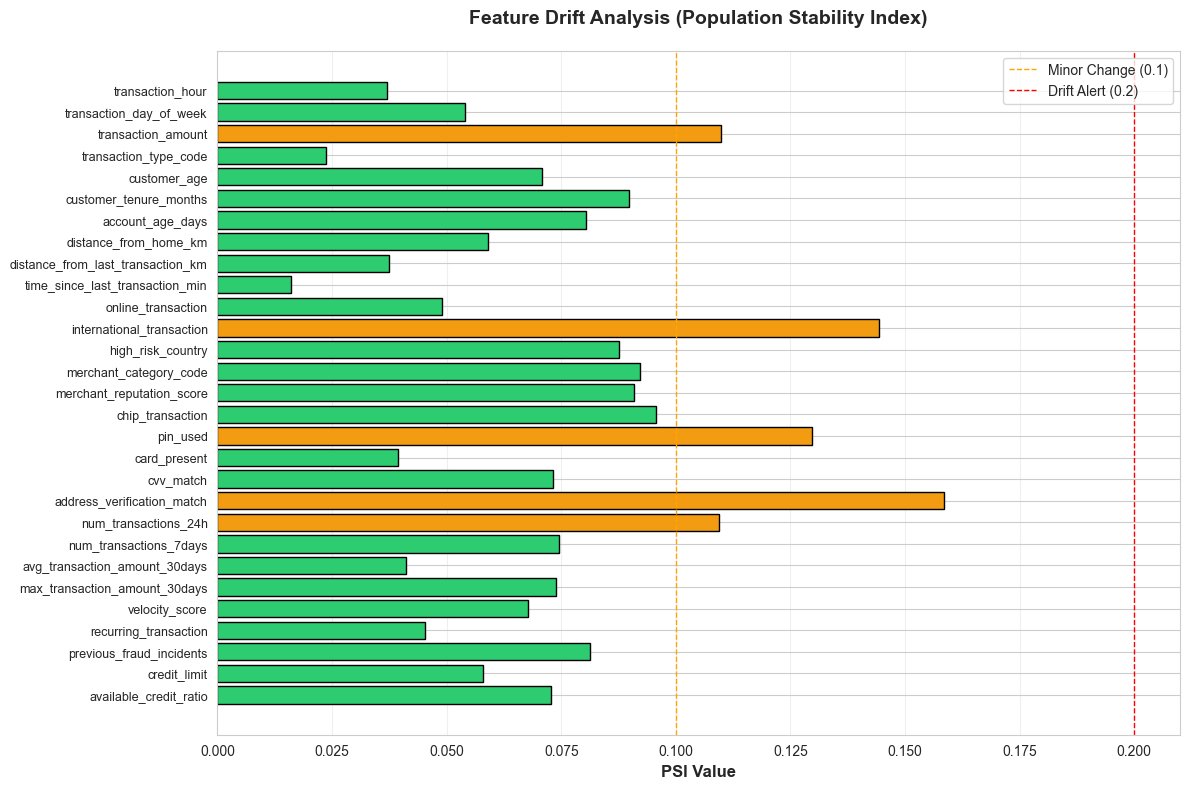


--- feature_drift_comparison ---


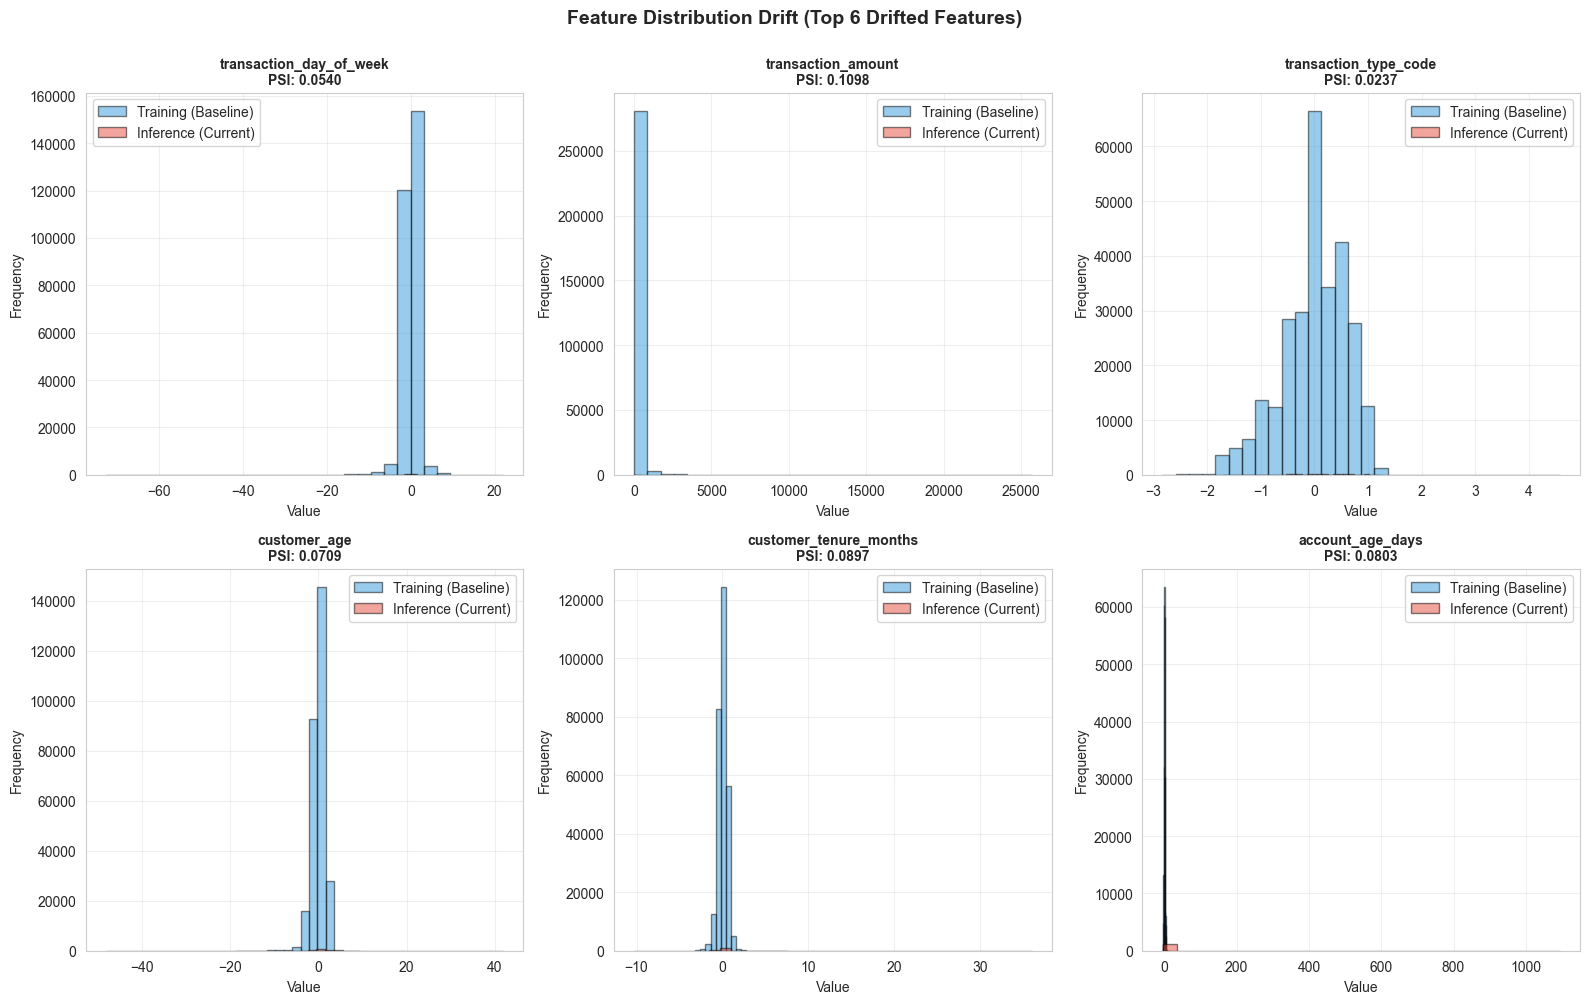


--- drift_summary_dashboard ---


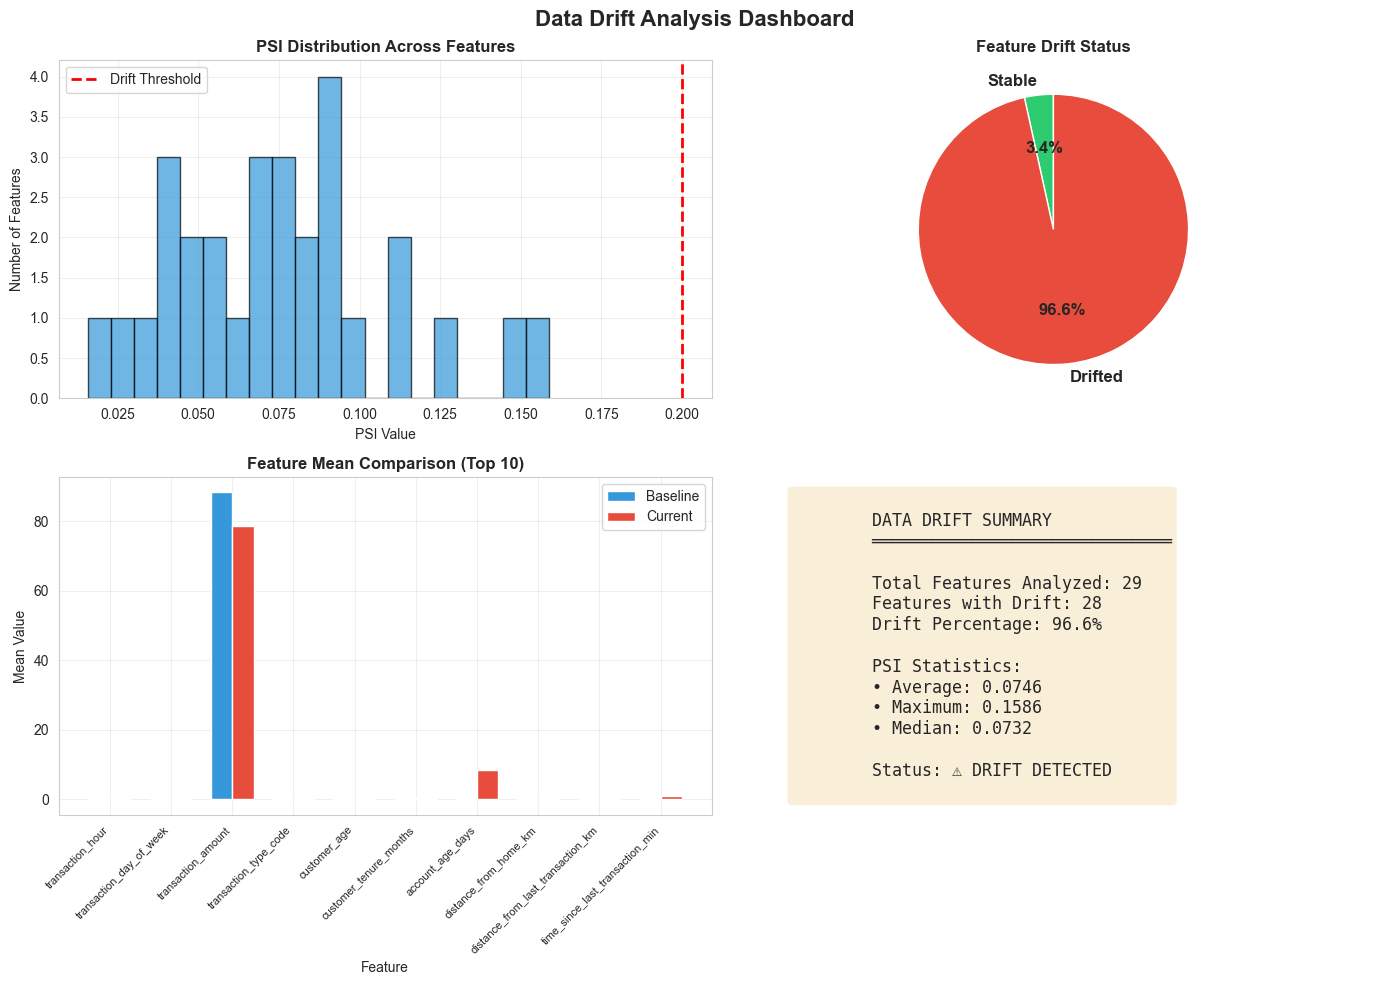


✓ Generated 3 data drift charts


In [22]:
# Generate and display data drift charts inline
if not inference_raw.empty and 'drift_results' in dir() and drift_results.get('features'):
    drift_figures = create_drift_visualizations(
        baseline_data=baseline_numeric[common_features],
        current_data=inference_numeric,
        drift_results=drift_results,
        feature_names=common_features,
        output_dir='/tmp/drift_charts',
    )

    for name, fig in drift_figures.items():
        print(f'\n--- {name} ---')
        display(fig)

    print(f'\n✓ Generated {len(drift_figures)} data drift charts')
else:
    print('No drift results available to visualize.')

### 📊 KS-Specific Visualizations (Enhanced Drift Detection)

The Kolmogorov-Smirnov (KS) test provides enhanced sensitivity to distribution changes, especially in tails.

**KS Advantages for Fraud Detection:**
- **Tail sensitivity**: Detects rare fraud pattern changes
- **Distribution-free**: No assumptions about underlying distributions
- **Comprehensive**: Captures both location and shape changes
- **Interpretable**: Direct measure of maximum CDF difference

2026-03-15 20:31:45,512 - INFO - Creating KS CDF comparison plots for top 10 drifted features...


Creating KS-specific visualizations...

📈 KS CDF Comparison Plots


2026-03-15 20:31:47,496 - INFO - ✓ Saved KS CDF comparison plot: /tmp/drift_charts/ks_cdf_comparison.png
2026-03-15 20:31:47,497 - INFO - ✓ Created KS CDF comparison plots for 10 features



--- ks_cdf_comparison ---


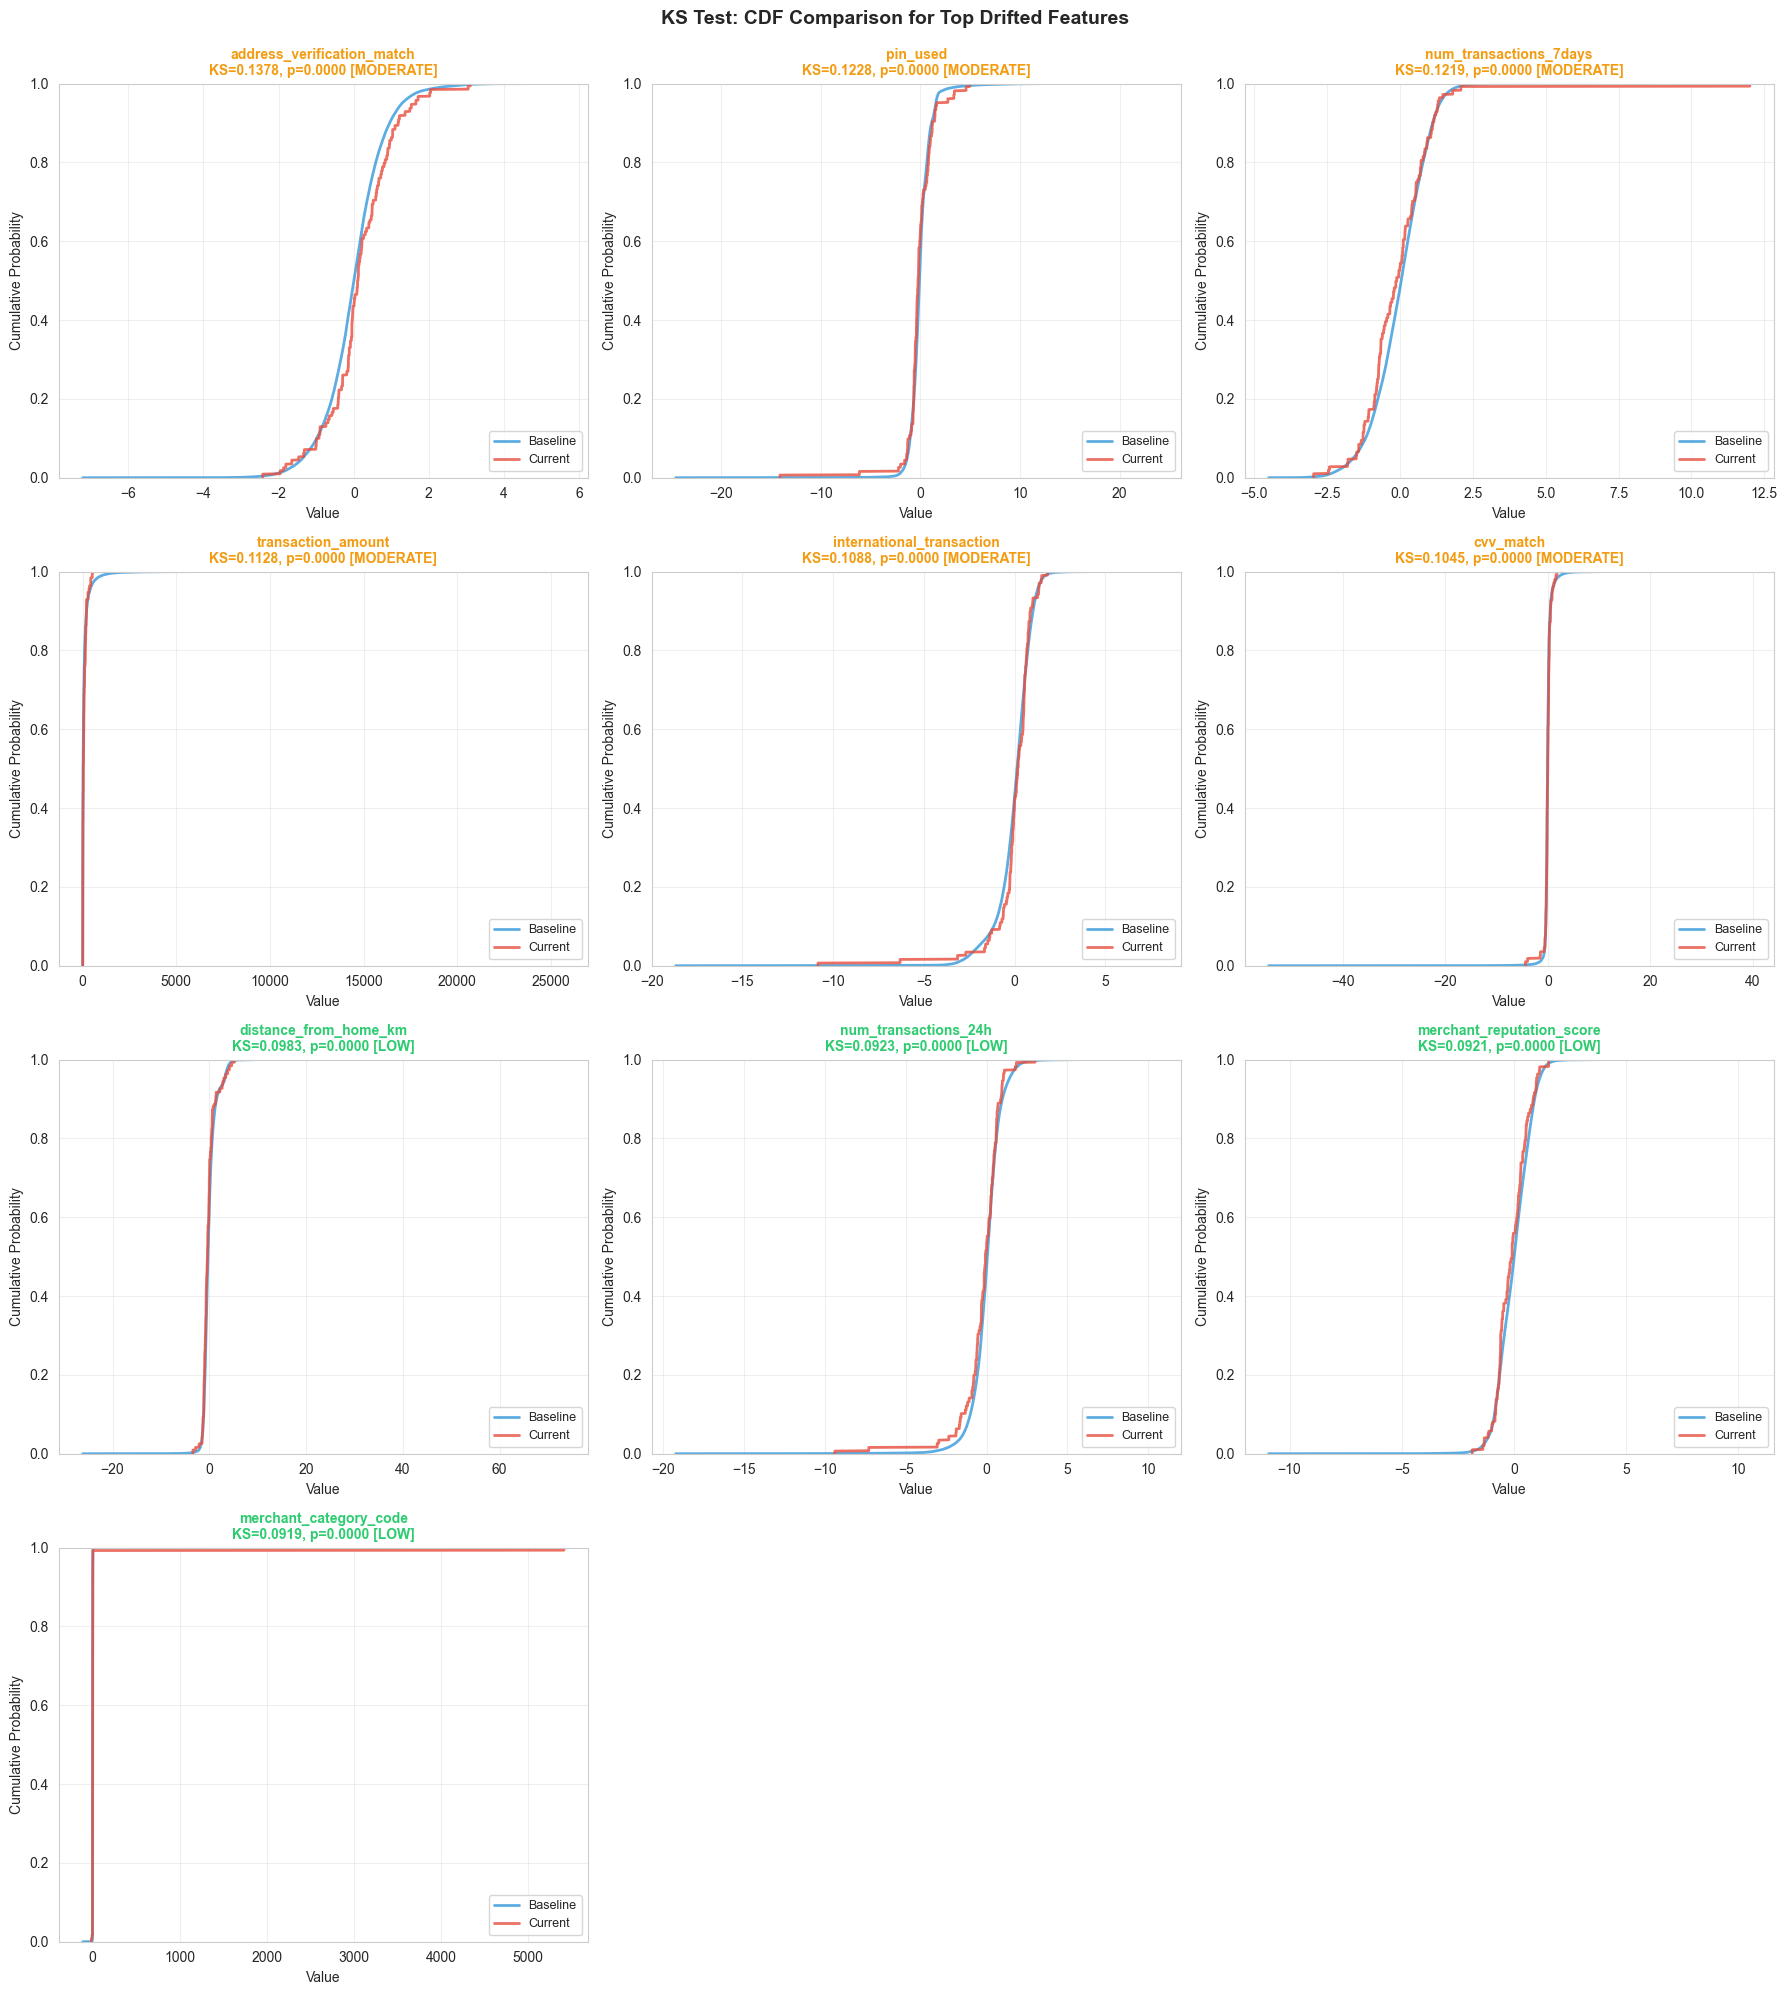

2026-03-15 20:31:48,404 - INFO - Creating KS statistics heatmap...


✓ Generated 1 KS CDF comparison plots

📊 KS Statistics Heatmap


2026-03-15 20:31:49,050 - INFO - ✓ Saved KS statistics heatmap: /tmp/drift_charts/ks_statistics_heatmap.png
2026-03-15 20:31:49,051 - INFO - ✓ Created KS statistics heatmap for 29 features



--- ks_statistics_heatmap ---


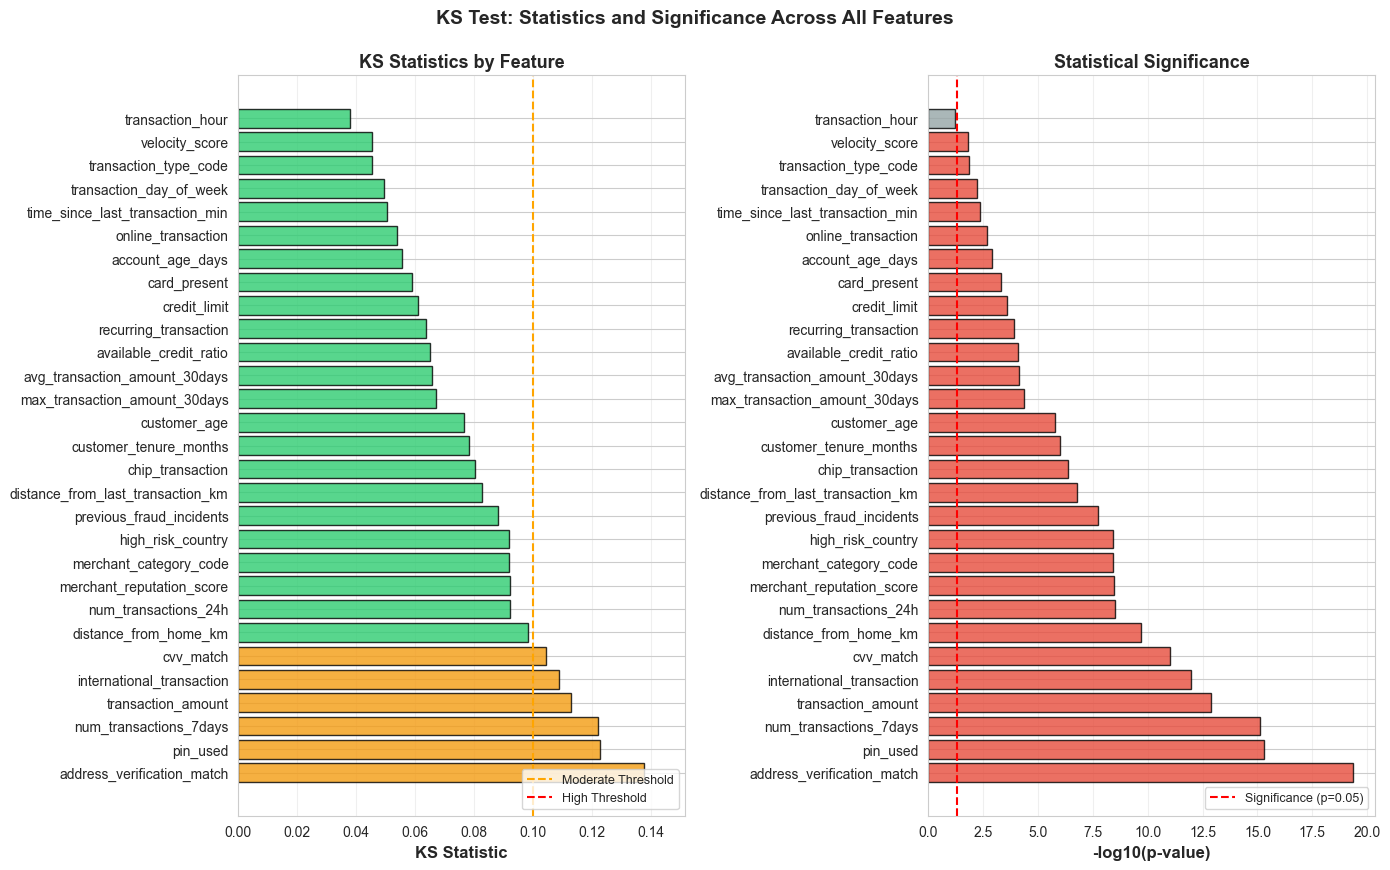

✓ Generated 1 KS heatmap visualizations

📋 KS Test Summary
Total features analyzed: 29
Features with significant drift (p < 0.05): 28
Features with moderate drift (KS > 0.1): 6
Features with high drift (KS > 0.2): 0

Top 5 Features by KS Statistic:
  1. 🟠 address_verification_match     KS=0.1378, p=0.0000
  2. 🟠 pin_used                       KS=0.1228, p=0.0000
  3. 🟠 num_transactions_7days         KS=0.1219, p=0.0000
  4. 🟠 transaction_amount             KS=0.1128, p=0.0000
  5. 🟠 international_transaction      KS=0.1088, p=0.0000

✓ KS-specific visualizations complete


In [23]:
# Generate KS-specific visualizations
if not inference_raw.empty and 'drift_results' in dir() and drift_results.get('features'):
    print("Creating KS-specific visualizations...")
    
    # 1. KS CDF Comparison Plots
    print("\n📈 KS CDF Comparison Plots")
    print("=" * 80)
    ks_cdf_figures = create_ks_cdf_comparison_plots(
        baseline_data=baseline_numeric[common_features],
        current_data=inference_numeric,
        drift_results=drift_results,
        feature_names=common_features,
        output_dir='/tmp/drift_charts',
        max_features=10
    )
    
    for name, fig in ks_cdf_figures.items():
        print(f'\n--- {name} ---')
        display(fig)
    
    print(f'✓ Generated {len(ks_cdf_figures)} KS CDF comparison plots')
    
    # 2. KS Statistics Heatmap
    print("\n📊 KS Statistics Heatmap")
    print("=" * 80)
    ks_heatmap_figures = create_ks_statistics_heatmap(
        drift_results=drift_results,
        feature_names=common_features,
        output_dir='/tmp/drift_charts'
    )
    
    for name, fig in ks_heatmap_figures.items():
        print(f'\n--- {name} ---')
        display(fig)
    
    print(f'✓ Generated {len(ks_heatmap_figures)} KS heatmap visualizations')
    
    # 3. KS Summary Statistics
    print("\n📋 KS Test Summary")
    print("=" * 80)
    
    ks_stats = []
    for feature, stats in drift_results['features'].items():
        if 'ks_statistic' in stats:
            ks_stats.append({
                'feature': feature,
                'ks_stat': stats['ks_statistic'],
                'p_value': stats.get('ks_pvalue', stats.get('p_value', 0)),
                'drifted': stats.get('drift_detected', False)
            })
    
    ks_stats_sorted = sorted(ks_stats, key=lambda x: x['ks_stat'], reverse=True)
    
    print(f"Total features analyzed: {len(ks_stats)}")
    print(f"Features with significant drift (p < 0.05): {sum(1 for s in ks_stats if s['p_value'] < 0.05)}")
    print(f"Features with moderate drift (KS > 0.1): {sum(1 for s in ks_stats if s['ks_stat'] > 0.1)}")
    print(f"Features with high drift (KS > 0.2): {sum(1 for s in ks_stats if s['ks_stat'] > 0.2)}")
    
    print("\nTop 5 Features by KS Statistic:")
    for i, stat in enumerate(ks_stats_sorted[:5], 1):
        drift_indicator = "🔴" if stat['ks_stat'] > 0.2 else "🟠" if stat['ks_stat'] > 0.1 else "🟢"
        print(f"  {i}. {drift_indicator} {stat['feature']:30s} KS={stat['ks_stat']:.4f}, p={stat['p_value']:.4f}")
    
    print("=" * 80)
    print("\n✓ KS-specific visualizations complete")
else:
    print('No drift results available for KS visualization.')


### 4.2 Model Drift Detection

In [24]:
from src.pipeline.pipeline_steps.inference_monitoring import detect_model_drift

# Load predictions with ground truth
gt_df = monitor.load_predictions_with_ground_truth(endpoint_name=ENDPOINT_NAME, days=30)

if len(gt_df) >= 50:
    y_true = gt_df['ground_truth'].values
    y_proba = gt_df['probability_fraud'].values

    # Baseline metrics from training (update these with your actual training metrics)
    baseline_metrics = {
        'roc_auc': 0.92,
        'pr_auc': 0.65,
        'precision': 0.85,
        'recall': 0.78,
        'f1_score': 0.81,
    }

    model_drift = detect_model_drift(
        y_true=y_true,
        y_pred_proba=y_proba,
        baseline_metrics=baseline_metrics,
        threshold_degradation=0.05,  # 5% degradation threshold
    )

    print('Model Drift Results:')
    print(f"  Drift detected: {model_drift['drift_detected']}")
    print(f"\n  Current vs Baseline:")
    for metric, info in model_drift['degradation'].items():
        status = '⚠ DRIFT' if info['drift_detected'] else '✓ OK'
        current = model_drift['current_metrics'][metric]
        baseline = baseline_metrics[metric]
        print(f"    {metric}: {current:.4f} (baseline: {baseline:.4f}, change: {info['percentage']:+.1f}%) {status}")
else:
    print(f'Insufficient ground truth data ({len(gt_df)} samples). Need at least 50.')
    print('Run ground truth update (Section 3) first.')

2026-03-15 20:32:08,879 - INFO - Loading predictions with ground truth...
2026-03-15 20:32:08,880 - INFO - Executing query: 
        SELECT
            inference_id,
            request_timestamp,
            endpoint_name,
...
2026-03-15 20:32:12,532 - INFO - Query returned 1191 rows
2026-03-15 20:32:12,533 - INFO - Loaded 1,191 predictions with ground truth
2026-03-15 20:32:12,533 - INFO - Detecting model drift...
2026-03-15 20:32:12,546 - WARNING - ⚠ Model drift detected in 'roc_auc': dropped from 0.9200 to 0.5684 (38.2% degradation)
2026-03-15 20:32:12,547 - WARNING - ⚠ Model drift detected in 'pr_auc': dropped from 0.6500 to 0.2345 (63.9% degradation)
2026-03-15 20:32:12,548 - WARNING - ⚠ Model drift detected in 'precision': dropped from 0.8500 to 0.7368 (13.3% degradation)
2026-03-15 20:32:12,548 - WARNING - ⚠ Model drift detected in 'recall': dropped from 0.7800 to 0.0897 (88.5% degradation)
2026-03-15 20:32:12,548 - WARNING - ⚠ Model drift detected in 'f1_score': dropped from 0

Model Drift Results:
  Drift detected: True

  Current vs Baseline:
    roc_auc: 0.5684 (baseline: 0.9200, change: +38.2%) ⚠ DRIFT
    pr_auc: 0.2345 (baseline: 0.6500, change: +63.9%) ⚠ DRIFT
    precision: 0.7368 (baseline: 0.8500, change: +13.3%) ⚠ DRIFT
    recall: 0.0897 (baseline: 0.7800, change: +88.5%) ⚠ DRIFT
    f1_score: 0.1600 (baseline: 0.8100, change: +80.2%) ⚠ DRIFT


2026-03-15 20:32:16,713 - INFO - Creating model drift comparison...
/Users/skoppar/workspace/pure-storage-mlflow/src/sagemaker/pipeline_steps/inference_monitoring.py:1187: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels([m.replace('_', ' ').title() for m in metrics])
/Users/skoppar/workspace/pure-storage-mlflow/src/sagemaker/pipeline_steps/inference_monitoring.py:1196: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
2026-03-15 20:32:16,810 - INFO - ✓ Created 1 model drift visualizations
/Users/skoppar/workspace/pure-storage-mlflow/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)



--- model_drift_comparison ---


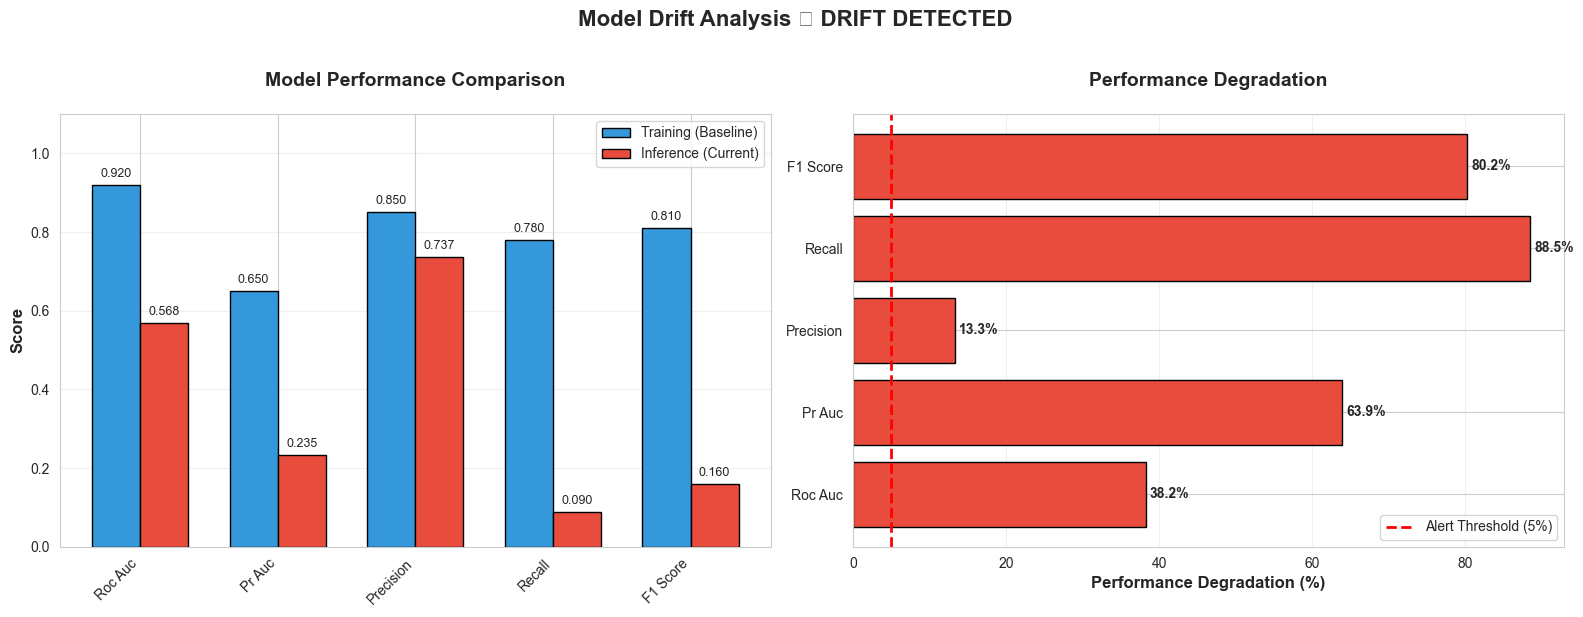


✓ Generated 1 model drift charts


In [25]:
# Generate and display model drift charts inline
if 'model_drift' in dir() and model_drift:
    model_drift_figures = create_model_drift_visualizations(
        model_drift_results=model_drift,
        output_dir='/tmp/model_drift_charts',
    )

    for name, fig in model_drift_figures.items():
        print(f'\n--- {name} ---')
        display(fig)

    print(f'\n✓ Generated {len(model_drift_figures)} model drift charts')
else:
    print('No model drift results available to visualize. Need ground truth data (Section 3).')

### 4.3 Log Monitoring Results to MLflow

In [26]:
# Log monitoring results and charts to MLflow
MLFLOW_TRACKING_URI = os.getenv('MLFLOW_TRACKING_URI')

if MLFLOW_TRACKING_URI:
    try:
        import mlflow
        mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
        mlflow.set_experiment('credit-card-fraud-detection-monitoring')

        with mlflow.start_run(run_name=f'monitoring-{datetime.utcnow().strftime("%Y%m%d-%H%M")}'):
            # Log overall metrics
            if report.get('overall_metrics') and 'error' not in report['overall_metrics']:
                for k, v in report['overall_metrics'].items():
                    if isinstance(v, (int, float)) and v is not None:
                        mlflow.log_metric(f'monitor_{k}', v)

            # Log drift summary
            if 'drift_results' in dir() and drift_results:
                summary = drift_results.get('summary', {})
                mlflow.log_metric('drift_features_count', summary.get('drifted_features_count', 0))
                mlflow.log_metric('drift_avg_psi', summary.get('avg_psi', 0))
                mlflow.log_metric('drift_max_psi', summary.get('max_psi', 0))
                
                # Log KS-specific metrics
                if 'avg_ks_statistic' in summary:
                    mlflow.log_metric('ks_avg_statistic', summary.get('avg_ks_statistic', 0))
                    mlflow.log_metric('ks_max_statistic', summary.get('max_ks_statistic', 0))
                    mlflow.log_metric('ks_median_statistic', summary.get('median_ks_statistic', 0))
                    mlflow.log_metric('ks_min_pvalue', summary.get('min_ks_pvalue', 1))
                    
                    # Count features by drift severity
                    ks_moderate = sum(1 for f in drift_results['features'].values() 
                                     if 0.1 <= f.get('ks_statistic', 0) < 0.2)
                    ks_high = sum(1 for f in drift_results['features'].values() 
                                 if f.get('ks_statistic', 0) >= 0.2)
                    ks_significant = sum(1 for f in drift_results['features'].values() 
                                        if f.get('ks_pvalue', 1) < 0.05)
                    
                    mlflow.log_metric('ks_features_moderate_drift', ks_moderate)
                    mlflow.log_metric('ks_features_high_drift', ks_high)
                    mlflow.log_metric('ks_features_significant', ks_significant)
                    
                    print(f'  ✓ Logged KS metrics: {ks_moderate} moderate, {ks_high} high drift features')

            # Log model drift
            if 'model_drift' in dir() and model_drift:
                mlflow.log_param('model_drift_detected', model_drift['drift_detected'])
                for metric, val in model_drift['current_metrics'].items():
                    mlflow.log_metric(f'current_{metric}', val)

            # Log drift charts as figures
            if 'drift_figures' in dir() and drift_figures:
                for name, fig in drift_figures.items():
                    try:
                        mlflow.log_figure(fig, f'drift_charts/{name}.png')
                    except Exception as e:
                        print(f'  ⚠ Could not log {name}: {e}')
            
            # Log KS-specific charts
            if 'ks_cdf_figures' in dir() and ks_cdf_figures:
                for name, fig in ks_cdf_figures.items():
                    try:
                        mlflow.log_figure(fig, f'ks_drift_charts/{name}.png')
                        print(f'  ✓ Logged KS CDF chart: {name}')
                    except Exception as e:
                        print(f'  ⚠ Could not log {name}: {e}')
            
            if 'ks_heatmap_figures' in dir() and ks_heatmap_figures:
                for name, fig in ks_heatmap_figures.items():
                    try:
                        mlflow.log_figure(fig, f'ks_drift_charts/{name}.png')
                        print(f'  ✓ Logged KS heatmap: {name}')
                    except Exception as e:
                        print(f'  ⚠ Could not log {name}: {e}')

            if 'model_drift_figures' in dir() and model_drift_figures:
                for name, fig in model_drift_figures.items():
                    try:
                        mlflow.log_figure(fig, f'model_drift_charts/{name}.png')
                    except Exception as e:
                        print(f'  ⚠ Could not log {name}: {e}')

            # Tags
            mlflow.set_tags({
                'pipeline_step': 'monitoring',
                'endpoint_name': ENDPOINT_NAME,
                'stat_test': 'ks',  # Indicate KS test is being used
            })

            print(f'✓ Monitoring results and charts logged to MLflow')
            print(f'  Tracking URI: {MLFLOW_TRACKING_URI}')
            print(f'  Experiment: credit-card-fraud-detection-monitoring')

    except Exception as e:
        print(f'⚠ Failed to log to MLflow: {e}')
else:
    print('MLFLOW_TRACKING_URI not set. Skipping MLflow logging.')
    print('Set it in .env to enable: MLFLOW_TRACKING_URI=arn:aws:sagemaker:...')


2026-03-15 20:32:22,614 - INFO - Loading cached SSO token for default
/var/folders/x7/t3b9975n6_z57y4hq5d6yhfc0000gr/T/ipykernel_56480/893221114.py:10: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  with mlflow.start_run(run_name=f'monitoring-{datetime.utcnow().strftime("%Y%m%d-%H%M")}'):
2026-03-15 20:32:26,740 - INFO - Loading cached SSO token for default
2026-03-15 20:32:28,048 - INFO - Loading cached SSO token for default
2026-03-15 20:32:29,416 - INFO - Loading cached SSO token for default
2026-03-15 20:32:30,707 - INFO - Loading cached SSO token for default
2026-03-15 20:32:31,873 - INFO - Loading cached SSO token for default
2026-03-15 20:32:33,064 - INFO - Loading cached SSO token for default
2026-03-15 20:32:34,299 - INFO - Loading cached SSO token for default
2026-03-15 20:32:35,451 - INFO - Loading cached SSO token for 

  ✓ Logged KS metrics: 6 moderate, 0 high drift features


2026-03-15 20:32:59,912 - INFO - Loading cached SSO token for default
2026-03-15 20:33:01,065 - INFO - Loading cached SSO token for default
2026-03-15 20:33:02,418 - INFO - Loading cached SSO token for default
2026-03-15 20:33:03,500 - INFO - Loading cached SSO token for default
2026-03-15 20:33:05,251 - INFO - Loading cached SSO token for default
2026-03-15 20:33:06,888 - INFO - Loading cached SSO token for default


  ✓ Logged KS CDF chart: ks_cdf_comparison
  ✓ Logged KS heatmap: ks_statistics_heatmap


/Users/skoppar/workspace/pure-storage-mlflow/.venv/lib/python3.12/site-packages/mlflow/tracking/client.py:2882: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  figure.savefig(tmp_path, **save_kwargs)
2026-03-15 20:33:13,807 - INFO - Loading cached SSO token for default


✓ Monitoring results and charts logged to MLflow
  Tracking URI: arn:aws:sagemaker:us-east-1:146666888814:mlflow-app/app-VG5VVXAMF5GQ
  Experiment: credit-card-fraud-detection-monitoring


2026-03-15 20:33:14,911 - INFO - Loading cached SSO token for default
2026-03-15 20:33:16,080 - INFO - Loading cached SSO token for default


🏃 View run monitoring-20260316-0332 at: https://mlflow.sagemaker.us-east-1.app.aws/#/experiments/3/runs/b8c2bf33d28c48dbb6052ee64490e500
🧪 View experiment at: https://mlflow.sagemaker.us-east-1.app.aws/#/experiments/3


### 4.4 Performance Alerts

In [42]:
# Check for performance degradation alerts
alerts = report.get('alerts', [])

if alerts:
    print(f'⚠ {len(alerts)} performance alert(s) detected:\n')
    for alert in alerts:
        print(f"  [{alert['severity'].upper()}] Period: {alert['period']}")
        print(f"    ROC-AUC: {alert['value']:.4f} (baseline: {alert['baseline']:.4f})")
        print(f"    Degradation: {alert['degradation_pct']:.1f}%")
        print(f"    Samples: {alert['sample_count']:,}")
        print()
else:
    print('✓ No performance degradation alerts. Model is performing within thresholds.')

⚠ 2 performance alert(s) detected:

  [CRITICAL] Period: 2026-02-21 00:00:00
    ROC-AUC: 0.5858 (baseline: 0.5295)
    Degradation: -10.6%
    Samples: 900

  [CRITICAL] Period: 2026-02-22 00:00:00
    ROC-AUC: 0.4733 (baseline: 0.5295)
    Degradation: 10.6%
    Samples: 184



In [43]:
# Re-import in case kernel was restarted between cells
import sys
from pathlib import Path

_project_root = Path.cwd()
while not (_project_root / '.env').exists() and _project_root != _project_root.parent:
    _project_root = _project_root.parent
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

from src.config.config import AWS_REGION
REGION = AWS_REGION
ENDPOINT_NAME = globals().get('ENDPOINT_NAME', 'fraud-detector-endpoint')

# Create CloudWatch Dashboard and Alarms for Drift Monitoring
import boto3
import json
from datetime import datetime, timezone

cw_client = boto3.client('cloudwatch', region_name=REGION)

NAMESPACE = 'FraudDetection/DriftMonitoring'
DASHBOARD_NAME = 'FraudDetection-DriftMonitoring'
DRIFT_THRESHOLD = 0.10  # 10% variance threshold

print("=" * 80)
print("Creating CloudWatch Dashboard and Drift Alarms")
print("=" * 80)

# Step 1: Publish current drift metrics to CloudWatch
print("\nStep 1: Publishing drift metrics to CloudWatch...")

metrics_to_publish = []

# Data drift metrics
if 'drift_results' in dir() and drift_results:
    summary = drift_results.get('summary', {})
    avg_psi = summary.get('avg_psi', 0)
    max_psi = summary.get('max_psi', 0)
    drift_pct = summary.get('drift_percentage', 0)

    metrics_to_publish.extend([
        {'MetricName': 'DataDrift-AvgPSI', 'Value': avg_psi, 'Unit': 'None'},
        {'MetricName': 'DataDrift-MaxPSI', 'Value': max_psi, 'Unit': 'None'},
        {'MetricName': 'DataDrift-DriftedFeaturesPct', 'Value': drift_pct, 'Unit': 'Percent'},
    ])

    # Per-feature PSI
    for feat_name, feat_info in drift_results.get('features', {}).items():
        metrics_to_publish.append({
            'MetricName': f'DataDrift-PSI-{feat_name}',
            'Value': feat_info.get('psi', 0),
            'Unit': 'None',
        })

    print(f"  Data drift: Avg PSI={avg_psi:.4f}, Max PSI={max_psi:.4f}, Drifted={drift_pct:.1f}%")

# Model drift metrics
if 'model_drift' in dir() and model_drift:
    current = model_drift.get('current_metrics', {})
    degradation = model_drift.get('degradation', {})

    for metric_name, metric_val in current.items():
        metrics_to_publish.append({
            'MetricName': f'ModelDrift-Current-{metric_name}',
            'Value': metric_val,
            'Unit': 'None',
        })

    for metric_name, deg_info in degradation.items():
        metrics_to_publish.append({
            'MetricName': f'ModelDrift-Degradation-{metric_name}',
            'Value': abs(deg_info.get('percentage', 0)) / 100.0,  # Normalize to 0-1
            'Unit': 'None',
        })

    print(f"  Model drift detected: {model_drift.get('drift_detected', False)}")
    for m, v in current.items():
        print(f"    {m}: {v:.4f}")

# Publish all metrics
if metrics_to_publish:
    now = datetime.now(timezone.utc)
    metric_data = [
        {
            'MetricName': m['MetricName'],
            'Timestamp': now,
            'Value': m['Value'],
            'Unit': m['Unit'],
            'Dimensions': [
                {'Name': 'Endpoint', 'Value': ENDPOINT_NAME},
            ]
        }
        for m in metrics_to_publish
    ]

    # CloudWatch accepts max 1000 metrics per call, batch in groups of 25
    for i in range(0, len(metric_data), 25):
        batch = metric_data[i:i+25]
        cw_client.put_metric_data(Namespace=NAMESPACE, MetricData=batch)

    print(f"\n  Published {len(metrics_to_publish)} metrics to CloudWatch namespace: {NAMESPACE}")
else:
    print("\n  No drift metrics available. Run drift detection cells first.")

# Step 2: Create CloudWatch Alarms
print("\nStep 2: Creating CloudWatch Alarms (10% variance threshold)...")

alarms_created = []

# Data Drift Alarm: PSI > 0.2 (standard threshold for significant shift)
try:
    cw_client.put_metric_alarm(
        AlarmName='FraudDetection-DataDrift-PSI',
        AlarmDescription='Data drift detected: Average PSI exceeds 0.2 (significant distribution shift)',
        Namespace=NAMESPACE,
        MetricName='DataDrift-MaxPSI',
        Dimensions=[{'Name': 'Endpoint', 'Value': ENDPOINT_NAME}],
        Statistic='Maximum',
        Period=3600,  # 1 hour
        EvaluationPeriods=1,
        Threshold=0.2,
        ComparisonOperator='GreaterThanThreshold',
        TreatMissingData='notBreaching',
    )
    alarms_created.append('FraudDetection-DataDrift-PSI (threshold: PSI > 0.2)')
except Exception as e:
    print(f"  Failed to create PSI alarm: {e}")

# Model Drift Alarms: > 10% degradation for each key metric
model_drift_alarms = {
    'roc_auc': 'ROC-AUC degradation exceeds 10%',
    'pr_auc': 'PR-AUC degradation exceeds 10%',
    'precision': 'Precision degradation exceeds 10%',
    'recall': 'Recall degradation exceeds 10%',
}

for metric_name, description in model_drift_alarms.items():
    alarm_name = f'FraudDetection-ModelDrift-{metric_name.replace("_", "-").upper()}'
    try:
        cw_client.put_metric_alarm(
            AlarmName=alarm_name,
            AlarmDescription=description,
            Namespace=NAMESPACE,
            MetricName=f'ModelDrift-Degradation-{metric_name}',
            Dimensions=[{'Name': 'Endpoint', 'Value': ENDPOINT_NAME}],
            Statistic='Maximum',
            Period=3600,  # 1 hour
            EvaluationPeriods=1,
            Threshold=DRIFT_THRESHOLD,  # 10% = 0.10
            ComparisonOperator='GreaterThanThreshold',
            TreatMissingData='notBreaching',
        )
        alarms_created.append(f'{alarm_name} (threshold: > {DRIFT_THRESHOLD*100:.0f}%)')
    except Exception as e:
        print(f"  Failed to create {alarm_name}: {e}")

print(f"  Created {len(alarms_created)} alarms:")
for a in alarms_created:
    print(f"    {a}")

# Step 3: Create CloudWatch Dashboard
print(f"\nStep 3: Creating CloudWatch Dashboard: {DASHBOARD_NAME}...")

dashboard_body = {
    "widgets": [
        {
            "type": "text",
            "x": 0, "y": 0, "width": 24, "height": 2,
            "properties": {
                "markdown": f"# Fraud Detection - Drift Monitoring Dashboard\n**Endpoint:** `{ENDPOINT_NAME}` | **Threshold:** 10% variance | **Updated:** {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M UTC')}"
            }
        },
        {
            "type": "metric",
            "x": 0, "y": 2, "width": 12, "height": 6,
            "properties": {
                "title": "Data Drift - PSI Scores",
                "metrics": [
                    [NAMESPACE, "DataDrift-AvgPSI", "Endpoint", ENDPOINT_NAME, {"label": "Avg PSI", "stat": "Maximum"}],
                    [NAMESPACE, "DataDrift-MaxPSI", "Endpoint", ENDPOINT_NAME, {"label": "Max PSI", "stat": "Maximum"}],
                ],
                "view": "timeSeries",
                "stacked": False,
                "period": 3600,
                "region": REGION,
                "annotations": {
                    "horizontal": [
                        {"label": "Significant Drift", "value": 0.2, "color": "#d62728"},
                        {"label": "Moderate Drift", "value": 0.1, "color": "#ff7f0e"},
                    ]
                },
                "yAxis": {"left": {"min": 0, "max": 1}},
            }
        },
        {
            "type": "metric",
            "x": 12, "y": 2, "width": 12, "height": 6,
            "properties": {
                "title": "Data Drift - Drifted Features %",
                "metrics": [
                    [NAMESPACE, "DataDrift-DriftedFeaturesPct", "Endpoint", ENDPOINT_NAME, {"label": "Drifted %", "stat": "Maximum"}],
                ],
                "view": "timeSeries",
                "period": 3600,
                "region": REGION,
                "yAxis": {"left": {"min": 0, "max": 100}},
            }
        },
        {
            "type": "metric",
            "x": 0, "y": 8, "width": 12, "height": 6,
            "properties": {
                "title": "Model Performance - Current Metrics",
                "metrics": [
                    [NAMESPACE, "ModelDrift-Current-roc_auc", "Endpoint", ENDPOINT_NAME, {"label": "ROC-AUC", "stat": "Maximum"}],
                    [NAMESPACE, "ModelDrift-Current-pr_auc", "Endpoint", ENDPOINT_NAME, {"label": "PR-AUC", "stat": "Maximum"}],
                    [NAMESPACE, "ModelDrift-Current-precision", "Endpoint", ENDPOINT_NAME, {"label": "Precision", "stat": "Maximum"}],
                    [NAMESPACE, "ModelDrift-Current-recall", "Endpoint", ENDPOINT_NAME, {"label": "Recall", "stat": "Maximum"}],
                    [NAMESPACE, "ModelDrift-Current-f1_score", "Endpoint", ENDPOINT_NAME, {"label": "F1-Score", "stat": "Maximum"}],
                ],
                "view": "timeSeries",
                "stacked": False,
                "period": 3600,
                "region": REGION,
                "yAxis": {"left": {"min": 0, "max": 1}},
            }
        },
        {
            "type": "metric",
            "x": 12, "y": 8, "width": 12, "height": 6,
            "properties": {
                "title": "Model Drift - Degradation from Baseline (10% alarm threshold)",
                "metrics": [
                    [NAMESPACE, "ModelDrift-Degradation-roc_auc", "Endpoint", ENDPOINT_NAME, {"label": "ROC-AUC Degradation", "stat": "Maximum"}],
                    [NAMESPACE, "ModelDrift-Degradation-pr_auc", "Endpoint", ENDPOINT_NAME, {"label": "PR-AUC Degradation", "stat": "Maximum"}],
                    [NAMESPACE, "ModelDrift-Degradation-precision", "Endpoint", ENDPOINT_NAME, {"label": "Precision Degradation", "stat": "Maximum"}],
                    [NAMESPACE, "ModelDrift-Degradation-recall", "Endpoint", ENDPOINT_NAME, {"label": "Recall Degradation", "stat": "Maximum"}],
                ],
                "view": "timeSeries",
                "stacked": False,
                "period": 3600,
                "region": REGION,
                "annotations": {
                    "horizontal": [
                        {"label": "10% Alarm Threshold", "value": 0.10, "color": "#d62728"},
                    ]
                },
                "yAxis": {"left": {"min": 0, "max": 1}},
            }
        },
        {
            "type": "alarm",
            "x": 0, "y": 14, "width": 24, "height": 3,
            "properties": {
                "title": "Drift Alarms Status",
                "alarms": [
                    f"arn:aws:cloudwatch:{REGION}:{boto3.client('sts').get_caller_identity()['Account']}:alarm:FraudDetection-DataDrift-PSI",
                    f"arn:aws:cloudwatch:{REGION}:{boto3.client('sts').get_caller_identity()['Account']}:alarm:FraudDetection-ModelDrift-ROC-AUC",
                    f"arn:aws:cloudwatch:{REGION}:{boto3.client('sts').get_caller_identity()['Account']}:alarm:FraudDetection-ModelDrift-PR-AUC",
                    f"arn:aws:cloudwatch:{REGION}:{boto3.client('sts').get_caller_identity()['Account']}:alarm:FraudDetection-ModelDrift-PRECISION",
                    f"arn:aws:cloudwatch:{REGION}:{boto3.client('sts').get_caller_identity()['Account']}:alarm:FraudDetection-ModelDrift-RECALL",
                ]
            }
        },
    ]
}

try:
    cw_client.put_dashboard(
        DashboardName=DASHBOARD_NAME,
        DashboardBody=json.dumps(dashboard_body),
    )
    print(f"  Dashboard created: {DASHBOARD_NAME}")
except Exception as e:
    print(f"  Failed to create dashboard: {e}")

# Summary
account_id = boto3.client('sts').get_caller_identity()['Account']
dashboard_url = f"https://console.aws.amazon.com/cloudwatch/home?region={REGION}#dashboards:name={DASHBOARD_NAME}"

print("\n" + "=" * 80)
print("CloudWatch Drift Monitoring Setup Complete")
print("=" * 80)
print(f"\nDashboard URL:")
print(f"  {dashboard_url}")
print(f"\nAlarms ({len(alarms_created)}):")
for a in alarms_created:
    print(f"  {a}")
print(f"\nMetrics Namespace: {NAMESPACE}")
print(f"Metrics Published: {len(metrics_to_publish)}")
print(f"\nTo add email notifications:")
print(f"  1. Create an SNS topic: aws sns create-topic --name FraudDetection-DriftAlerts")
print(f"  2. Subscribe: aws sns subscribe --topic-arn <arn> --protocol email --notification-endpoint your@email.com")
print(f"  3. Add to alarms: Update each alarm with AlarmActions=[<topic-arn>]")
print("=" * 80)

Creating CloudWatch Dashboard and Drift Alarms

Step 1: Publishing drift metrics to CloudWatch...
  Data drift: Avg PSI=0.0748, Max PSI=0.1588, Drifted=96.6%
  Model drift detected: True
    roc_auc: 0.5647
    pr_auc: 0.2357
    precision: 0.7647
    recall: 0.0929
    f1_score: 0.1656

  Published 42 metrics to CloudWatch namespace: FraudDetection/DriftMonitoring

Step 2: Creating CloudWatch Alarms (10% variance threshold)...
  Created 5 alarms:
    FraudDetection-DataDrift-PSI (threshold: PSI > 0.2)
    FraudDetection-ModelDrift-ROC-AUC (threshold: > 10%)
    FraudDetection-ModelDrift-PR-AUC (threshold: > 10%)
    FraudDetection-ModelDrift-PRECISION (threshold: > 10%)
    FraudDetection-ModelDrift-RECALL (threshold: > 10%)

Step 3: Creating CloudWatch Dashboard: FraudDetection-DriftMonitoring...
  Failed to create dashboard: An error occurred (AccessDenied) when calling the PutDashboard operation: User: arn:aws:sts::YOUR_ACCOUNT_ID:assumed-role/AmazonSageMaker-ExecutionRole-20250722

### 4.5 CloudWatch Dashboard and Alarms

Create a CloudWatch dashboard to visualize drift metrics and alarms that trigger when data drift or model drift exceeds 10% variance.

**What gets created:**
- **Custom Metrics**: Data drift (PSI) and model drift (ROC-AUC, PR-AUC, precision, recall degradation) published to CloudWatch
- **Dashboard**: `FraudDetection-DriftMonitoring` with widgets for all drift metrics
- **Alarms**: Trigger when any metric exceeds 10% variance from baseline
  - `FraudDetection-DataDrift-PSI` — PSI > 0.2 (significant distribution shift)
  - `FraudDetection-ModelDrift-ROC-AUC` — ROC-AUC degradation > 10%
  - `FraudDetection-ModelDrift-PR-AUC` — PR-AUC degradation > 10%
  - `FraudDetection-ModelDrift-Precision` — Precision degradation > 10%
  - `FraudDetection-ModelDrift-Recall` — Recall degradation > 10%

**Note:** Alarms can be connected to SNS topics for email/Slack notifications.

---

## Summary

This notebook covers the full post-deployment monitoring loop:

| Step | What it does | When to run |
|------|-------------|-------------|
| **1. Single Test** | Verify endpoint is live and responding | After deployment |
| **2. Batch Transform** | Bulk score large datasets | Periodic (daily/weekly) |
| **3. Ground Truth** | Backfill confirmed labels | As investigations complete |
| **4. Monitoring** | Detect data/model drift | Continuous (scheduled) |

For production automation, use:
- `scripts/setup_scheduled_inference.py` — EventBridge + Lambda for real-time scoring
- `scripts/setup_scheduled_batch_transform.py` — Scheduled batch jobs
- `scripts/monitor_model_performance.py` — CLI for monitoring reports

## 3. Batch Transform (Optional)

> **Skip this section if your inference endpoint from `pipeline_execution.ipynb` is already live.**
> Batch Transform is only needed when you want to do bulk offline scoring without a live endpoint.
> If your endpoint is up and running, proceed directly to Section 3 (Ground Truth Update).

In [ ]:
# --- SKIP: Only needed if no live endpoint ---
# Uncomment this cell if you need batch transform (no live endpoint)
#
# import sagemaker
# from sagemaker.transformer import Transformer
#
# sagemaker_session = sagemaker.Session(boto_session=boto3.Session(region_name=REGION))
# bucket = sagemaker_session.default_bucket()
#
# Configuration — update MODEL_NAME to match your pipeline's CreateModel output
# MODEL_NAME = 'fraud-detector'  # SageMaker model name from pipeline
# BATCH_INPUT_PREFIX = f's3://{bucket}/fraud-detection/batch-input'
# BATCH_OUTPUT_PREFIX = f's3://{bucket}/fraud-detection/batch-output'
# BATCH_INSTANCE_TYPE = 'ml.m5.xlarge'
#
# print(f'Model: {MODEL_NAME}')
# print(f'Input: {BATCH_INPUT_PREFIX}')
# print(f'Output: {BATCH_OUTPUT_PREFIX}')

In [ ]:
# --- SKIP: Only needed if no live endpoint ---
# Uncomment this cell if you need batch transform (no live endpoint)
#
# Prepare batch input: export sample data to S3 as CSV
# XGBoost batch transform expects CSV without headers, no target column
# batch_df = test_df.sample(n=min(1000, len(test_df)), random_state=42)
#
# Drop target and non-numeric columns
# feature_df = batch_df.drop(
#     columns=['is_fraud', 'fraud_prediction', 'fraud_probability'],
#     errors='ignore'
# ).select_dtypes(include=[np.number])
#
# Save to S3
# timestamp = datetime.utcnow().strftime('%Y%m%d-%H%M%S')
# input_s3_path = f'{BATCH_INPUT_PREFIX}/{timestamp}/input.csv'
#
# feature_df.to_csv(f'/tmp/batch_input.csv', index=False, header=False)
#
# import boto3
# s3 = boto3.client('s3')
# s3_key = input_s3_path.replace(f's3://{bucket}/', '')
# s3.upload_file('/tmp/batch_input.csv', bucket, s3_key)
#
# print(f'Uploaded {len(feature_df)} samples to {input_s3_path}')
# print(f'Features: {feature_df.shape[1]} columns')

In [ ]:
# --- SKIP: Only needed if no live endpoint ---
# Uncomment this cell if you need batch transform (no live endpoint)
#
# Create and run batch transform job
# output_path = f'{BATCH_OUTPUT_PREFIX}/{timestamp}'
#
# transformer = Transformer(
#     model_name=MODEL_NAME,
#     instance_count=1,
#     instance_type=BATCH_INSTANCE_TYPE,
#     output_path=output_path,
#     sagemaker_session=sagemaker_session,
#     accept='text/csv',
#     strategy='MultiRecord',
#     max_payload=6,
# )
#
# print(f'Starting batch transform job...')
# print(f'  Input: {input_s3_path}')
# print(f'  Output: {output_path}')
#
# transformer.transform(
#     data=input_s3_path,
#     content_type='text/csv',
#     split_type='Line',
# )
#
# print('Waiting for batch transform to complete...')
# transformer.wait()
# print(f'✓ Batch transform complete. Output: {output_path}')

In [ ]:
# --- SKIP: Only needed if no live endpoint ---
# Uncomment this cell if you need batch transform (no live endpoint)
#
# Download and inspect batch results
# import io
#
# List output files
# output_prefix = output_path.replace(f's3://{bucket}/', '')
# response = s3.list_objects_v2(Bucket=bucket, Prefix=output_prefix)
#
# if 'Contents' in response:
#     for obj in response['Contents']:
#         print(f"Output file: s3://{bucket}/{obj['Key']} ({obj['Size']} bytes)")
#
#     # Read first output file
#     first_key = response['Contents'][0]['Key']
#     obj = s3.get_object(Bucket=bucket, Key=first_key)
#     content = obj['Body'].read().decode('utf-8')
#
#     # Parse predictions
#     preds = [float(line.strip()) for line in content.strip().split('\n') if line.strip()]
#     print(f'\nParsed {len(preds)} predictions')
#     print(f'Prediction range: [{min(preds):.4f}, {max(preds):.4f}]')
#     print(f'Mean prediction: {np.mean(preds):.4f}')
#     fraud_count = sum(1 for p in preds if p >= 0.5)
#     print(f'Fraud predictions (>=0.5): {fraud_count}/{len(preds)} ({fraud_count/len(preds)*100:.1f}%)')
# else:
#     print('No output files found')

## 6. Automated Drift Monitoring Setup

Set up EventBridge + Lambda + SNS for automated drift detection and alerting.

**What this does:**
- Creates SNS topic for email alerts
- Deploys Lambda function for drift detection
- Sets up EventBridge rule to run checks daily
- Sends email notifications when drift exceeds thresholds

**Thresholds:**
- Data Drift: PSI ≥ 0.2
- Model Drift: >5% performance degradation

### 6.1 Configure Email for Drift Alerts

In [ ]:
# Configure email for drift alerts
ALERT_EMAIL = "your-email@example.com"  # ← Change this to your email

# Optional: Customize thresholds
DATA_DRIFT_THRESHOLD = 0.2   # PSI threshold
MODEL_DRIFT_THRESHOLD = 0.05  # 5% performance degradation

# Optional: Customize schedule (default: daily at 2 AM UTC)
# SCHEDULE_EXPRESSION = "cron(0 2 * * ? *)"  # Daily at 2 AM UTC
# SCHEDULE_EXPRESSION = "cron(0 */6 * * ? *)"  # Every 6 hours
# SCHEDULE_EXPRESSION = "rate(1 day)"  # Every day

print(f"✓ Alert email: {ALERT_EMAIL}")
print(f"✓ Data drift threshold: PSI >= {DATA_DRIFT_THRESHOLD}")
print(f"✓ Model drift threshold: {MODEL_DRIFT_THRESHOLD * 100}% degradation")

### 6.2 Deploy Drift Monitoring Infrastructure

This cell creates:
1. **SNS Topic** - for sending email alerts
2. **Lambda Function** - runs drift detection logic
3. **IAM Role** - permissions for Lambda
4. **EventBridge Rule** - scheduled trigger (daily at 2 AM UTC)

**Note:** You'll receive an email confirmation link - click it to activate alerts!

In [ ]:
%%bash -s "$ALERT_EMAIL" "$DATA_DRIFT_THRESHOLD" "$MODEL_DRIFT_THRESHOLD"

# Deploy drift monitoring infrastructure
export ALERT_EMAIL=$1
export DATA_DRIFT_THRESHOLD=$2
export MODEL_DRIFT_THRESHOLD=$3
export ATHENA_DATABASE="fraud_detection"
export AWS_REGION="us-east-1"

# Get AWS Account ID
export AWS_ACCOUNT_ID=$(aws sts get-caller-identity --query Account --output text)
export ATHENA_OUTPUT_S3="s3://fraud-detection-data-lake-skoppar-${AWS_ACCOUNT_ID}/athena-query-results/"

echo "🚀 Deploying drift monitoring infrastructure..."
echo ""

cd ../../  # Go to project root
bash src/setup/deploy_drift_monitoring.sh

### 6.3 Verify Deployment

In [ ]:
# Load deployment configuration
import json
from pathlib import Path

config_path = Path('../../drift_monitoring_config.json')

if config_path.exists():
    with open(config_path) as f:
        config = json.load(f)

    print("✅ Drift Monitoring Infrastructure Deployed")
    print("=" * 80)
    print(f"SNS Topic ARN: {config['sns_topic_arn']}")
    print(f"Lambda Function ARN: {config['lambda_function_arn']}")
    print(f"EventBridge Rule ARN: {config['eventbridge_rule_arn']}")
    print(f"Schedule: {config['schedule']}")
    print(f"Data Drift Threshold: PSI >= {config['data_drift_threshold']}")
    print(f"Model Drift Threshold: {float(config['model_drift_threshold']) * 100}% degradation")
    
    if config.get('email'):
        print(f"\n⚠️ IMPORTANT: Check your email ({config['email']}) and confirm SNS subscription!")
else:
    print("❌ Configuration not found. Run the deployment cell above.")

### 6.4 Test Drift Monitoring (Manual Trigger)

Manually trigger the Lambda function to test drift detection without waiting for the scheduled run.

In [ ]:
import boto3
import json

lambda_client = boto3.client('lambda')

print("🧪 Testing drift monitoring Lambda function...")
print("=" * 80)

try:
    response = lambda_client.invoke(
        FunctionName='fraud-detection-drift-monitor',
        InvocationType='RequestResponse',
        LogType='Tail'
    )

    payload = json.loads(response['Payload'].read())
    
    if payload.get('statusCode') == 200:
        body = json.loads(payload['body'])
        
        print("✅ Drift monitoring check completed successfully")
        print("")
        print(f"Timestamp: {body['timestamp']}")
        print("")
        
        # Data drift results
        if body.get('data_drift'):
            dd = body['data_drift']
            print("📊 DATA DRIFT RESULTS:")
            print(f"  Features Analyzed: {dd.get('features_analyzed', 'N/A')}")
            print(f"  Drifted Features: {dd.get('drifted_features_count', 'N/A')}")
            print(f"  Drift Percentage: {dd.get('drift_percentage', 0):.1f}%")
            print(f"  Average PSI: {dd.get('avg_psi', 0):.4f}")
            print(f"  Max PSI: {dd.get('max_psi', 0):.4f}")
            print(f"  Status: {'🚨 DRIFT DETECTED' if dd.get('detected') else '✓ No drift'}")
            
            if dd.get('drifted_features'):
                print("\n  Top Drifted Features:")
                for feat in dd['drifted_features']:
                    print(f"    - {feat['feature']}: PSI={feat['psi']:.4f}")
        else:
            print("⚠️ Data drift: Insufficient samples")
        
        print("")
        
        # Model drift results
        if body.get('model_drift'):
            md = body['model_drift']
            print("🎯 MODEL DRIFT RESULTS:")
            print(f"  Baseline ROC-AUC: {md.get('baseline_roc_auc', 0):.4f}")
            print(f"  Current ROC-AUC: {md.get('current_roc_auc', 0):.4f}")
            print(f"  Degradation: {md.get('degradation', 0):.4f} ({md.get('degradation_pct', 0):.1f}%)")
            print(f"  Status: {'🚨 DRIFT DETECTED' if md.get('detected') else '✓ No drift'}")
        else:
            print("⚠️ Model drift: Insufficient ground truth samples")
        
        print("")
        print(f"Alert Sent: {'Yes' if body.get('alert_sent') else 'No'}")
        
    else:
        print(f"❌ Lambda returned error: {payload}")

except Exception as e:
    print(f"❌ Error invoking Lambda: {e}")
    import traceback
    traceback.print_exc()

### 6.5 View CloudWatch Logs

Monitor Lambda execution logs to see detailed drift detection output.

In [ ]:
%%bash

# View recent CloudWatch logs for drift monitoring Lambda
LOG_GROUP="/aws/lambda/fraud-detection-drift-monitor"

echo "📋 Recent Lambda execution logs:"
echo "=" * 80

# Get the latest log stream
LATEST_STREAM=$(aws logs describe-log-streams \
    --log-group-name "$LOG_GROUP" \
    --order-by LastEventTime \
    --descending \
    --max-items 1 \
    --query 'logStreams[0].logStreamName' \
    --output text 2>/dev/null)

if [ -n "$LATEST_STREAM" ] && [ "$LATEST_STREAM" != "None" ]; then
    echo "Latest log stream: $LATEST_STREAM"
    echo ""
    
    aws logs get-log-events \
        --log-group-name "$LOG_GROUP" \
        --log-stream-name "$LATEST_STREAM" \
        --limit 50 \
        --query 'events[*].message' \
        --output text
else
    echo "No logs found yet. Run the test cell above to generate logs."
fi

### 6.6 Update Monitoring Configuration

Modify thresholds or schedule without redeploying the entire infrastructure.

In [ ]:
import boto3

lambda_client = boto3.client('lambda')

# New configuration (adjust as needed)
NEW_DATA_DRIFT_THRESHOLD = 0.15  # Lower threshold = more sensitive
NEW_MODEL_DRIFT_THRESHOLD = 0.03  # 3% degradation

print("🔧 Updating Lambda configuration...")

try:
    response = lambda_client.update_function_configuration(
        FunctionName='fraud-detection-drift-monitor',
        Environment={
            'Variables': {
                'ATHENA_DATABASE': 'fraud_detection',
                'ATHENA_OUTPUT_S3': f's3://fraud-detection-data-lake-skoppar-{AWS_ACCOUNT_ID}/athena-query-results/',
                'SNS_TOPIC_ARN': config['sns_topic_arn'],
                'DATA_DRIFT_THRESHOLD': str(NEW_DATA_DRIFT_THRESHOLD),
                'MODEL_DRIFT_THRESHOLD': str(NEW_MODEL_DRIFT_THRESHOLD),
                'BASELINE_ROC_AUC': '0.92'
            }
        }
    )
    
    print("✅ Configuration updated successfully")
    print(f"  New data drift threshold: PSI >= {NEW_DATA_DRIFT_THRESHOLD}")
    print(f"  New model drift threshold: {NEW_MODEL_DRIFT_THRESHOLD * 100}% degradation")
    
except Exception as e:
    print(f"❌ Failed to update configuration: {e}")

### 6.7 Disable/Enable Monitoring

Temporarily disable or re-enable the EventBridge rule.

In [ ]:
import boto3

events = boto3.client('events')

# Set to 'ENABLED' or 'DISABLED'
DESIRED_STATE = 'ENABLED'  # Change to 'DISABLED' to stop monitoring

try:
    if DESIRED_STATE == 'DISABLED':
        events.disable_rule(Name='fraud-detection-drift-check')
        print("⏸️ Drift monitoring DISABLED")
    else:
        events.enable_rule(Name='fraud-detection-drift-check')
        print("▶️ Drift monitoring ENABLED")
        
    # Show current status
    rule = events.describe_rule(Name='fraud-detection-drift-check')
    print(f"\nCurrent status: {rule['State']}")
    print(f"Schedule: {rule['ScheduleExpression']}")
    
except Exception as e:
    print(f"❌ Error: {e}")